# Aqui esta la historia de como se me fueron ocurriendo las cosas

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import ListedColormap

import seaborn as sns

from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn_extra.cluster import KMedoids

In [2]:
from scripts import style
style.mpl_apply()  

In [3]:
materias = pd.read_excel('data/onedrive/Archivos2024/Materias estudiantes-profesores 2019-2025 P y O.xlsx')
materias_copy = materias.copy()

# Estandarizacion de la base de datos

En esta seccion se estandarizo la base de datos para que no haya alumnos repetidos que inflen la calificacion promedio de un profesor, o de una materia, etc. como los alumnos que revalidan materias y aparecen dos veces en la base de datos. Por ejemplo, yo salgo 2 veces en Calculo, 2 veces en Calculo II, etc.

In [4]:
print(materias.info())
materias.head()

<class 'pandas.DataFrame'>
RangeIndex: 27788 entries, 0 to 27787
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CLAVEALUMNO           27788 non-null  int64  
 1   CLAVECARRERA          27788 non-null  str    
 2   anio                  27788 non-null  int64  
 3   CLAVESESION           27788 non-null  str    
 4   NUMORDEN              27788 non-null  int64  
 5   CLAVEVARIANTEMATERIA  27788 non-null  str    
 6   DESCRIBEMATERIA       27788 non-null  str    
 7   CALIFICACION          27788 non-null  object 
 8   CLAVEPROFESOR         26740 non-null  float64
dtypes: float64(1), int64(3), object(1), str(4)
memory usage: 1.9+ MB
None


,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,159167,LAR,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,22473.0
1,165277,LAD,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,22473.0
2,162781,LII,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,22473.0
3,161869,LIM,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.9,22473.0
4,164732,LMK,2019,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,22473.0


In [5]:
materias.loc[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
3173,175199,LAT,2021,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
5191,175199,LDS,2023,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,NaN
6258,175199,LAT,2022,OTOÑO,0,MAT1022,CÁLCULO I,10,24827.0
14587,175199,LDS,2023,OTOÑO,0,MAT2012,CÁLCULO II,10,NaN
20218,175199,LDS,2023,OTOÑO,0,MAT1022,CÁLCULO I,10,NaN
26000,175199,LAT,2023,PRIMAVERA,0,MAT2012,CÁLCULO II,10,23874.0
27589,175199,LAT,2022,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0


Hay NaNs en los profes porque son de las revalidadas

In [6]:
# IF CLAVEPROFESOR is nan and 'CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION' are the same, drop that row
materias.sort_values(by=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION', 'CLAVEPROFESOR'], inplace=True)
materias.drop_duplicates(subset=['CLAVEALUMNO', 'CLAVEVARIANTEMATERIA', 'CALIFICACION'], keep='first', inplace=True, ignore_index=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,NUMORDEN,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,0,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,0,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,0,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,0,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,0,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,0,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


In [7]:
materias['NUMORDEN'].nunique()

1

In [8]:
# drop NUMORDEN column
materias.drop(columns=['NUMORDEN'], inplace=True)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453.0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815.0
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109.0
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085.0
4,134718,LIS,2021,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,EQV,NaN
...,...,...,...,...,...,...,...,...
26640,403731,BNI,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.9,NaN
26641,403732,BBA,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,NaN
26642,403732,BBA,2022,OTOÑO,MAT1022,CÁLCULO I,9.6,NaN
26643,403732,BBA,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,9.2,NaN


Estas ya son mis calificaciones estandarizadas, sin repeticiones de alumnos en las materias.

In [9]:
materias[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
15962,175199,LAT,2021,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835.0
15963,175199,LAT,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897.0
15964,175199,LAT,2022,OTOÑO,MAT1022,CÁLCULO I,10,24827.0
15965,175199,LAT,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,23874.0


In [10]:
# count nans
materias['CLAVEPROFESOR'].isna().sum()

505

In [11]:
# drop the rows where CLAVEPROFESOR is nan
materias.dropna(subset=['CLAVEPROFESOR'], inplace=True)
# make the CLAVEPROFESOR column integer
materias['CLAVEPROFESOR'] = materias['CLAVEPROFESOR'].astype(int)

Bien!

Estas es el numero de alumnos unicos por profesor:  
Hay profesores con 969 alumnos! Wow! y un minimo de 26,30.

In [12]:
# clave profesor nunique
profes_value_counts = materias['CLAVEPROFESOR'].value_counts()
profes_value_counts

CLAVEPROFESOR
23452    969
23411    772
23152    726
24097    720
23852    719
        ... 
24328     40
21756     30
21226     30
22472     30
26078     26
Name: count, Length: 77, dtype: int64

# Ver distribucion de calificaciones por profesor!

Se  muestra el KDE porque luego imputaremos valores faltantes y queremos ver la distribucion de calificaciones sin esos valores faltantes.

In [13]:
profe1 = materias[materias['CLAVEPROFESOR'] == 23452]

In [14]:
profe1

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
82,156299,LAP,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.9,23452
173,159060,LIM,2022,OTOÑO,MAT1032,ÁLGEBRA LINEAL,7.5,23452
184,159185,LAR,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23452
306,160271,LBN,2019,OTOÑO,MAT2012,CÁLCULO II,9.3,23452
394,161021,LEC,2024,OTOÑO,MAT1022,CÁLCULO I,0,23452
...,...,...,...,...,...,...,...,...
26177,186320,LFB,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,23452
26206,186400,LNI,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.7,23452
26227,186441,LBN,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,23452
26264,186512,LFP,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.7,23452


In [15]:
# view the rows where CALIFICACION is not numeric
materias[~materias['CALIFICACION'].apply(lambda x: isinstance(x, (int, float)))]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
21,148182,LFP,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,BA,22767
24,149147,LNI,2025,PRIMAVERA,MAT1022,CÁLCULO I,BV,20792
26,149242,LPD,2023,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,RT,22109
29,149356,LMT,2019,OTOÑO,MAT1032,ÁLGEBRA LINEAL,RT,23149
...,...,...,...,...,...,...,...,...
26393,187782,LADM,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BA,25487
26394,187795,LCN,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23434
26397,187834,LIS,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23887
26398,187846,LBN,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23887


In [16]:
# keep the numeric calificacion numeric only
profe1num = profe1[pd.to_numeric(profe1['CALIFICACION'], errors='coerce').notnull()]
profe1num

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
82,156299,LAP,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.9,23452
173,159060,LIM,2022,OTOÑO,MAT1032,ÁLGEBRA LINEAL,7.5,23452
306,160271,LBN,2019,OTOÑO,MAT2012,CÁLCULO II,9.3,23452
394,161021,LEC,2024,OTOÑO,MAT1022,CÁLCULO I,0,23452
845,162163,LAR,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,1.2,23452
...,...,...,...,...,...,...,...,...
26177,186320,LFB,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,9.6,23452
26206,186400,LNI,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.7,23452
26227,186441,LBN,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.6,23452
26264,186512,LFP,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,6.7,23452


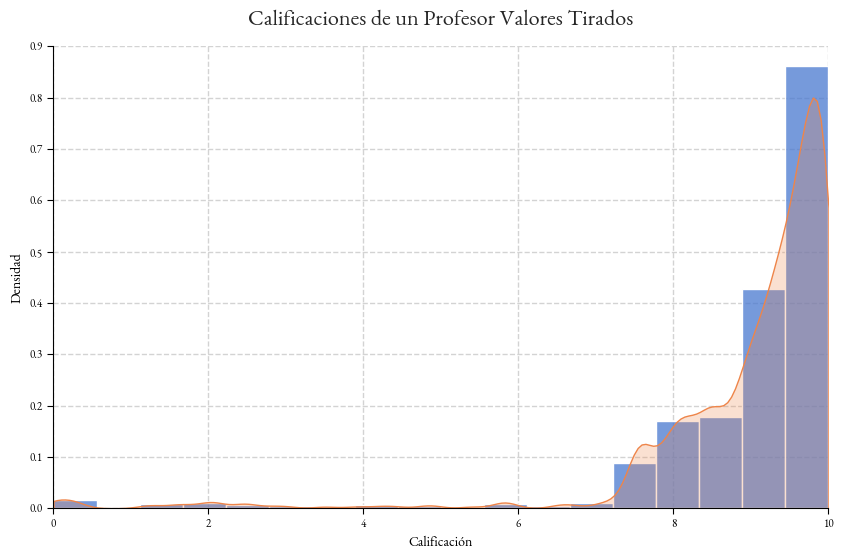

In [17]:
# plot the histogram of calificacion
plt.figure(figsize=(10, 6))
# use seaborn's 'stat' parameter instead of 'density' to avoid Matplotlib/Seaborn incompatibility
sns.histplot(profe1num['CALIFICACION'].astype(float), bins=18, stat='density')
sns.kdeplot(profe1num['CALIFICACION'].astype(float), cut=0, bw_adjust=0.4, fill=True)
plt.title('Calificaciones de un Profesor Valores Tirados')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.show()

In [18]:
# clave profesor nunique
profes_ids = materias['CLAVEPROFESOR'].unique()
profes_ids

array([23453, 21815, 22109, 24085, 23152, 24097, 23162, 23425, 23885,
       21228, 23468, 23434, 23411, 22446, 22767, 25093, 20792, 22091,
       22115, 24117, 23149, 23824, 23133, 23836, 23096, 22471, 23874,
       23852, 21779, 23839, 23837, 22521, 22503, 23887, 21854, 21852,
       16164, 21756, 23452, 23823, 23897, 18269, 24086, 20566, 23978,
       21853, 23859, 21262, 22114, 20529, 22473, 23218, 15282, 23148,
       21226, 22474, 22480, 23799, 23442, 23835, 20530, 24013, 24510,
       21192, 25487, 23153, 12516, 24328, 24827, 25496, 25503, 25843,
       25494, 22472, 25531, 26078, 25510])

# Ver la distribucion de calificaciones de los profesores

In [19]:
profes_value_counts 

CLAVEPROFESOR
23452    969
23411    772
23152    726
24097    720
23852    719
        ... 
24328     40
21756     30
21226     30
22472     30
26078     26
Name: count, Length: 77, dtype: int64

<Axes: xlabel='CALIFICACION', ylabel='Density'>

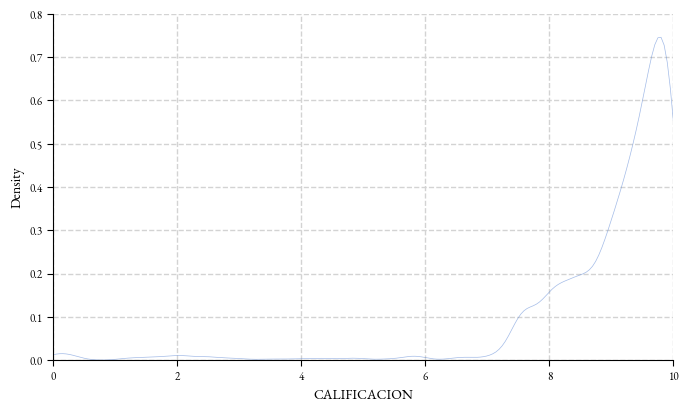

In [20]:
num = 0
profe2 = materias[materias['CLAVEPROFESOR'] == 23452]
profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]

# plot only the kde, not the histogram, cut from 0 to 10
sns.kdeplot(profe2num['CALIFICACION'], 
            cut=0, 
            bw_adjust=0.5, 
            clip=(0, 10), 
            label=f'Profesor {profes_ids[num]}', 
            alpha=0.5,  
            linewidth=0.5)

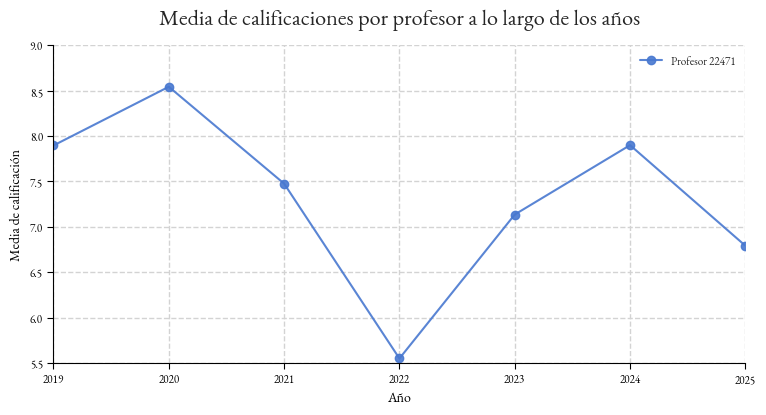

In [21]:
unique_profesores = materias['CLAVEPROFESOR'].nunique()
unique_profesores

means = []
variances = []

for profe in profes_ids:
    profe_data = materias[materias['CLAVEPROFESOR'] == profe]
    means_by_year = profe_data.groupby('anio')['CALIFICACION'].agg(lambda x: pd.to_numeric(x, errors='coerce').mean())
    means.append(means_by_year)
    variances.append(means_by_year.var())

# plot the means of each profesor of the top 10 profesores with highest variance
sorted_indices = np.argsort(variances)[63:-13]
for i in sorted_indices:
    mean = means[i]
    plt.plot(mean.index, mean.values, marker='o', linestyle='-', label=f'Profesor {profes_ids[i]}', alpha=0.9)
plt.legend()
plt.title('Media de calificaciones por profesor a lo largo de los años')
plt.xlabel('Año')
plt.ylabel('Media de calificación')
plt.tight_layout()
plt.savefig('visualizations/nb_04reportes_raw/06_00.pdf', bbox_inches='tight')
plt.show()
    

In [22]:
np.sort(variances)

array([0.00357185, 0.01053345, 0.01228097, 0.0191624 , 0.02204024,
       0.02756136, 0.03010774, 0.03143894, 0.03274657, 0.0359537 ,
       0.04306347, 0.05018614, 0.0502518 , 0.05063249, 0.05219167,
       0.05532195, 0.05745664, 0.05814521, 0.06088201, 0.06343964,
       0.06802052, 0.07444691, 0.07458662, 0.07619451, 0.08701797,
       0.10421499, 0.10908717, 0.11612931, 0.13087901, 0.14069153,
       0.14214735, 0.15531964, 0.1748389 , 0.19766872, 0.19812843,
       0.21424095, 0.25090733, 0.25873932, 0.26577528, 0.28013161,
       0.28756498, 0.29882396, 0.30308741, 0.33299571, 0.34353883,
       0.34819208, 0.37536629, 0.38439513, 0.39269403, 0.39360526,
       0.42490141, 0.42842266, 0.44977688, 0.49550049, 0.51625911,
       0.54550962, 0.5475814 , 0.59144075, 0.60527931, 0.62247737,
       0.64580263, 0.69238517, 0.71636389, 0.937426  ,        nan,
              nan,        nan,        nan,        nan,        nan,
              nan,        nan,        nan,        nan,        

In [23]:
np.sort(variances)[50:-13]

array([0.42490141, 0.42842266, 0.44977688, 0.49550049, 0.51625911,
       0.54550962, 0.5475814 , 0.59144075, 0.60527931, 0.62247737,
       0.64580263, 0.69238517, 0.71636389, 0.937426  ])

In [24]:
profes_ids[num]

23453

In [25]:
# assign colors based on the counts
# for example 23452.0    969, this professor should have the darkest color and 26078.0     26, the lightest color
# first we do a min max scaling of the counts to 0-1

scaler = MinMaxScaler()
counts = profes_value_counts.values.reshape(-1, 1) # this -1, 1 makes it a 2D array
scaled_counts = scaler.fit_transform(counts)

In [26]:
# assign colors of viridis based on the scaled counts, the higher the count, the brighter the color
colors = [sns.color_palette("viridis_r", 100)[int(scaled_counts[i][0]*99)] for i in range(len(scaled_counts))]

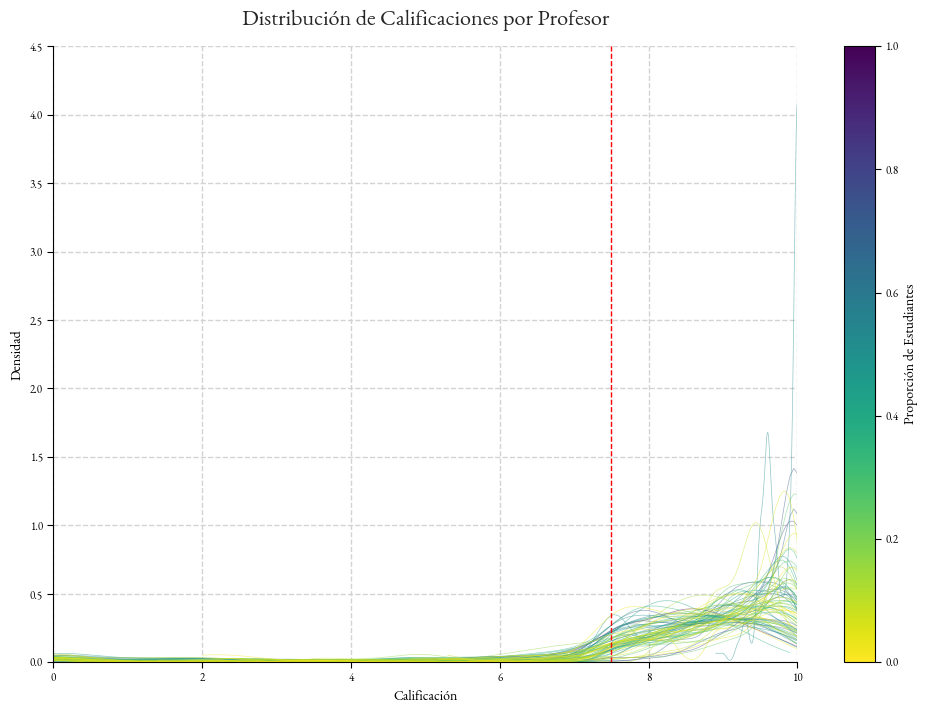

In [27]:
plt.figure(figsize=(12, 8))
ax = plt.gca()
for num in range(len(profes_ids)):
    profe2 = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue
    # plot only the kde, not the histogram, cut from 0 to 10
    sns.kdeplot(profe2num['CALIFICACION'], 
                cut=0, 
                bw_adjust=0.5, 
                clip=(0, 10), 
                label=f'Profesor {profes_ids[num]}', 
                alpha=0.5,  
                linewidth=0.5,
                color=colors[num])

# add a colorbar
sm = plt.cm.ScalarMappable(cmap='viridis_r', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de Estudiantes')



plt.title('Distribución de Calificaciones por Profesor')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.axvline(x=7.5, color='red', linestyle='--', linewidth=1, label='Límite Aprobatorio (7.5)')
plt.savefig('visualizations/profes_distributions/all_professors.png', bbox_inches='tight')
plt.show()

In [28]:


# ---- color scaling by counts (your code kept) ----
scaler = MinMaxScaler()
counts = profes_value_counts.values.reshape(-1, 1)
scaled_counts = scaler.fit_transform(counts)

viridis_by_prof = [sns.color_palette("Blues_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]
magma_by_prof = [sns.color_palette("Reds_r", 100)[int(scaled_counts[i][0]*50)]
                   for i in range(len(scaled_counts))]

threshold = 7.5

In [29]:
# calculate the percentage of CALIFICACION above and below the threshold for each professor
below_threshold_percentages = []
above_threshold_percentages = []
for num in range(len(profes_ids)):
    profe = materias[materias['CLAVEPROFESOR'] == profes_ids[num]]
    profe_num = profe[pd.to_numeric(profe['CALIFICACION'], errors='coerce').notnull()]
    calificaciones = profe_num['CALIFICACION'].astype(float)
    total_count = len(calificaciones)
    if total_count == 0:
        below_threshold_percentages.append(0)
        above_threshold_percentages.append(0)
        continue
    below_count = (calificaciones < threshold).sum()
    above_count = (calificaciones >= threshold).sum()
    below_threshold_percentages.append(below_count / total_count)
    above_threshold_percentages.append(above_count / total_count)

# get the mean
mean_below = np.mean(below_threshold_percentages)
mean_above = np.mean(above_threshold_percentages)

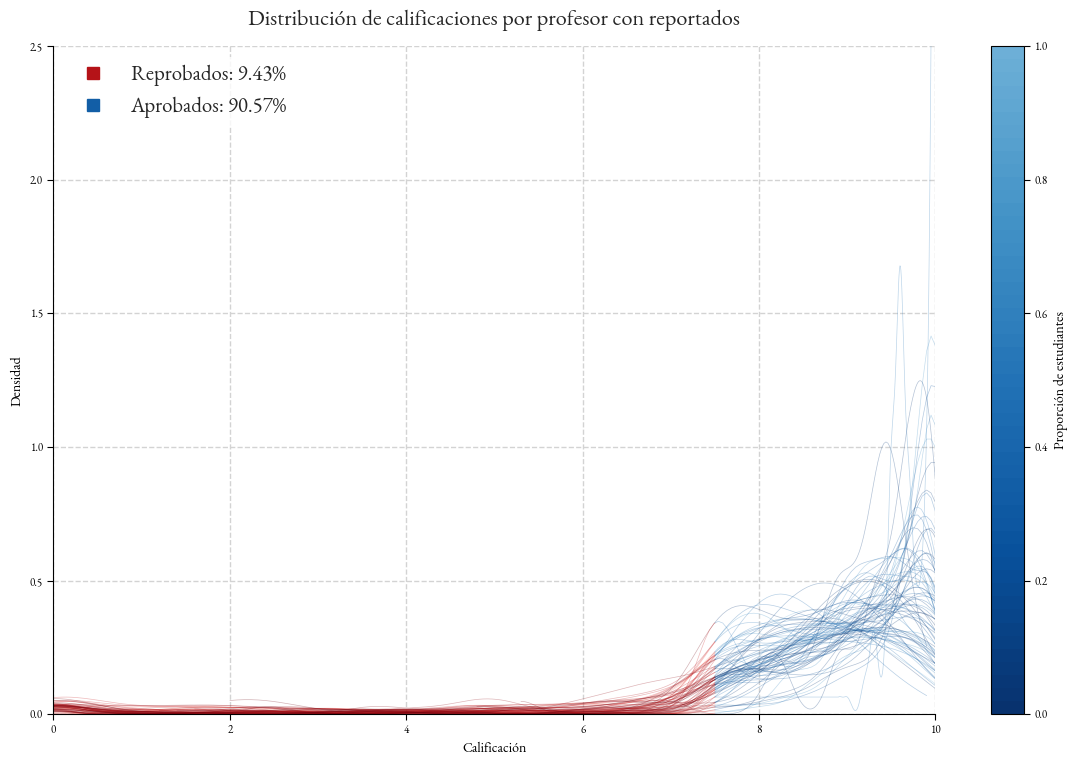

In [30]:


fig, ax = plt.subplots(figsize=(12, 8))

for num, prof_id in enumerate(profes_ids):
    profe2 = materias[materias['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['CALIFICACION'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de calificaciones por profesor con reportados')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad')

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

ax.set_xlim(0, 10)
ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de estudiantes')

plt.tight_layout()
plt.savefig('visualizations/profes_distributions/all_professors_colors_yzoom25.png', bbox_inches='tight')
plt.show()

Se muestarn unicamente los estudiantes que recibieron calificacion, es decir, si la dieron de baja o tuvieron retiro no aparecen en el plot. Son 26140 registros de materias desde 2019 a 2024. el color de la linea indica el numero de estudiantes que tuvo el profesor durante este periodo de tiempo, de color rojo son los estudiantes por debajo de 7.5 (reprobados) y de color azul los estudiantes por encima de 7.5 (aprobados). 

In [31]:
materias.shape

(26140, 8)

In [32]:
materias['anio'].unique()

array([2020, 2019, 2022, 2024, 2023, 2021, 2025], dtype=int64)

# Imputacion de valores faltantes

En esta seccion se prueban distintos metodos de imputacion de calificaciones

# Sin imputacion

In [33]:
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152
...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149


In [34]:
# view where there are not numeric calificaciones in materias
materias[~pd.to_numeric(materias['CALIFICACION'], errors='coerce').notnull()]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
21,148182,LFP,2022,OTOÑO,MAT2022,ESTADÍSTICA PARA NEGOCIOS I,BA,22767
24,149147,LNI,2025,PRIMAVERA,MAT1022,CÁLCULO I,BV,20792
26,149242,LPD,2023,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,RT,22109
29,149356,LMT,2019,OTOÑO,MAT1032,ÁLGEBRA LINEAL,RT,23149
...,...,...,...,...,...,...,...,...
26393,187782,LADM,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BA,25487
26394,187795,LCN,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23434
26397,187834,LIS,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23887
26398,187846,LBN,2025,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23887


In [35]:
profe_id = profes_ids[0]
profe_materias = materias[materias['CLAVEPROFESOR'] == profe_id]
profe_materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
54,153896,LAR,2020,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453
140,158815,LEC,2019,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.6,23453
206,159490,LHR,2019,OTOÑO,MAT1022,CÁLCULO I,BV,23453
223,159723,LFA,2019,PRIMAVERA,MAT1022,CÁLCULO I,9.9,23453
...,...,...,...,...,...,...,...,...
20140,179038,LAP,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453
20148,179047,LMK,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453
20167,179064,LMT,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
20172,179068,LFP,2022,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453


Se va a decir que un salon es aquel que tiene el mismo profesor, materia, anio y periodo.

In [36]:
# keep the columns where CLAVEPROFESOR=23453, CLAVEMATERIA=MAT1012, anio=2020
salon = materias[(materias['CLAVEPROFESOR'] == 23453) & (materias['CLAVEVARIANTEMATERIA'] == 'MAT1012') & (materias['anio'] == 2020) & (materias['CLAVESESION'] == 'PRIMAVERA')]
salon.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453


# Imputacion con la media y creacion de columna estandarizada

In [37]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

In [38]:
salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')].head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903


# Imputacion con KDE para no cambiar la distribucion de los que no tienen calificacion *asumiendo que estan debajo de 7.5*

In [39]:
def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float)
    k = 0
    # rejection sampling from KDE jitter
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        kept = draw[ok]
        take = min(len(kept), batch)
        if take:
            out[k:k+take] = kept[:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.5, min_kde_n=20, seed=42
):
    """
    Impute only NaNs in `value_col` by sampling a KDE fitted to observed values ≤ `high`.
    Observed values remain unchanged. Result in `out_col`.
    """
    rng = np.random.default_rng(seed)
    df = df.copy()

    # numeric projection
    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num  # start with numeric copy

    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df  # nothing to do

    obs_pre = num[~num.isna() & (num <= high)]
    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif len(obs_pre) > 0:
        draws = _sample_empirical(obs_pre.values, need, rng=rng)
        # ensure within bounds
        draws = np.clip(draws, low, high)
    else:
        # no support ≤ high; fallback constant within bounds
        draws = np.full(need, min(6.5, high), dtype=float)

    # assign only into NaNs
    df.loc[nan_mask, out_col] = draws
    # safety: clip only imputed entries (observed untouched)
    df.loc[nan_mask, out_col] = df.loc[nan_mask, out_col].clip(lower=low, upper=high)

    return df


In [40]:
salon = salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')]
salon.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903


In [41]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

In [42]:
# concat all the dataframes in salones into one dataframe called materias_imputed
salones_imp = pd.concat(salones.values(), ignore_index=True)

In [43]:
salones_imp.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014,3.906841,-1.026326
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662,0.500000,-2.321189
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880,5.300000,-0.496818
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729,7.500000,0.339352
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903,7.800000,0.453375


In [44]:
salon_imp = impute_nans_from_pre75_kde_df(salon, value_col='CALIFICACION', out_col='IMPKDE')
salon_imp.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014,3.906841
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662,0.500000
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880,5.300000
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729,7.500000
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903,7.800000


In [45]:
salon.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903


In [46]:
salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')].head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014,3.906841,-1.026326
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662,0.500000,-2.321189
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880,5.300000,-0.496818
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729,7.500000,0.339352
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903,7.800000,0.453375


In [47]:
# View where CALIFICACION is nan in salon
salon_imp.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,5.355,-0.639014,3.906841
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662,0.500000
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880,5.300000
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729,7.500000
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903,7.800000


In [48]:
# replace if not numeric to NaN in salon_imp
salon_imp['CALIFICACION'] = pd.to_numeric(salon_imp['CALIFICACION'], errors='coerce')
salon_imp[salon_imp['CALIFICACION'].isna()]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,3.906841
5316,166296,LIV,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,2.636772
5331,166299,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,7.161663
5632,166485,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,5.682025
6275,167055,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,4.787357
8182,168462,LEC,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,2.440839
8591,168674,LMT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,6.132134
8761,168800,LIS,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,1.205998
9780,169982,LHR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,5.800173
10141,170316,LBI,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,1.446586


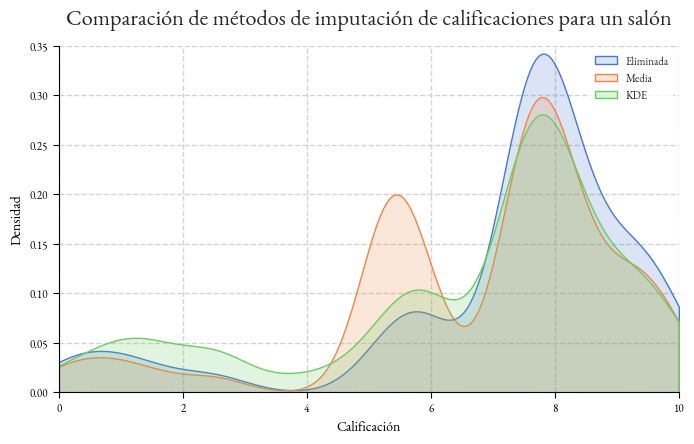

In [49]:
# plot the third subplot: dropped
sns.kdeplot(salon_imp['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, alpha=0.2, label='Eliminada')

sns.kdeplot(salon_imp['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='Media')

# z score the IMPKDE column
sns.kdeplot(salon_imp['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='KDE')

# plot the second subplot: mean imputed z score

plt.title('Comparación de métodos de imputación de calificaciones para un salón')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.legend()
plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison.png', bbox_inches='tight')
plt.savefig('visualizations/nb_04reportes_raw/05_01.pdf', bbox_inches='tight')
plt.show()

In [50]:
# if CALIFICACION is not numeric, make it NaN in materias_imputed
salones_imp['CALIFICACION'] = pd.to_numeric(salones_imp['CALIFICACION'], errors='coerce')


In [51]:
salones_imp.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,NaN,23453,5.355,-0.639014,3.906841,-1.026326
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0.500,-2.745662,0.500000,-2.321189
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,5.300,-0.662880,5.300000,-0.496818
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,7.500,0.291729,7.500000,0.339352
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,7.800,0.421903,7.800000,0.453375


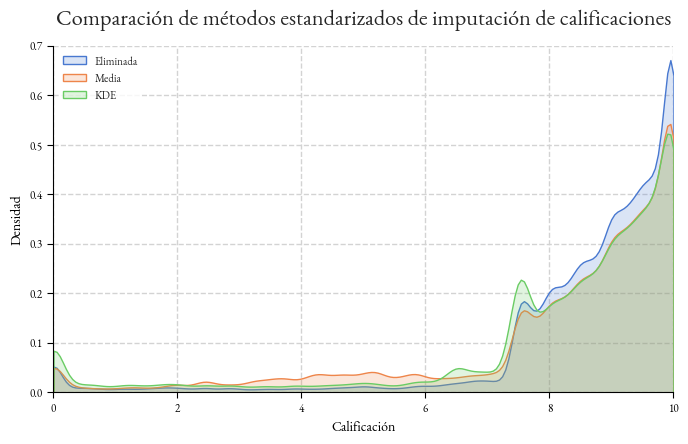

In [52]:
sns.kdeplot(salones_imp['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, alpha=0.2, label='Eliminada')

sns.kdeplot(salones_imp['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='Media')

# z score the IMPKDE column
sns.kdeplot(salones_imp['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='KDE')

# plot the second subplot: mean imputed z score

plt.title('Comparación de métodos estandarizados de imputación de calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.legend()
plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison_estandarizada.png', bbox_inches='tight')
plt.savefig('visualizations/nb_04reportes_raw/05_02.pdf', bbox_inches='tight')
plt.show()

# Pruebas de Hipotesis

In [53]:
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152
...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149


In [54]:
asesorias = pd.read_excel('data/onedrive/Archivos2024/Asesorias2024.xlsx')

In [55]:
asesorias

,fecha,id,carrera,semestre,profesor,materia,tema,periodo
0,2024-05-03 10:53:52,180214,Administración de Empresas,2,Ozkar Hernández Montero,Cálculo I,Aplicaciones de la integral,P
1,2024-05-02 12:01:42,179021,Física,4,Celic Teotetl Cárdenas Osorio,Ecuaciones Diferenciales Ordinarias,Edos,P
2,2024-05-02 12:00:17,177219,Estrategias Financieras y Contaduría Pública,4,Celic Teotetl Cárdenas Osorio,Estadística Para Negocios,Estadistica para negocios 2,P
3,2024-04-30 11:11:52,182618,Bioquímica Clínica,2,Daniela Rodríguez Tzompantzi,Cálculo I,Derivadas,P
4,2024-04-29 16:47:06,176657,Administración de Empresas,4,Paulino Antonio Gómez Salgado,Cálculo I,Límites de funciones,P
...,...,...,...,...,...,...,...,...
13495,2019-01-10 08:11:31,165047,Administración de Empresas,1,Efren Matlalcuatzi Rugerio,Matemáticas Universitarias,Funciones,P
13496,2019-01-10 08:10:44,166502,Ingeniería en Sistemas Computacionales,1,Gabriela López Pineda,Matemáticas Universitarias,Funciones,P
13497,2019-01-10 08:10:06,166960,Biología,1,Gabriela López Pineda,Matemáticas Universitarias,Funciones,P
13498,2019-01-10 07:18:44,162836,Ingeniería Mecánica,3,Efren Matlalcuatzi Rugerio,Cálculo II,Sucesiones y series,P


In [56]:
# count how many times each id appears in 'id' column
asesoria_counts = asesorias['id'].value_counts()
asesoria_counts

id
178529    116
172458    114
175999     70
140079     49
177664     49
         ... 
162994      1
163018      1
162750      1
166502      1
168426      1
Name: count, Length: 3355, dtype: int64

In [57]:
# if id in materias['CLAVEALUMNO'] but not in asesoria_counts, assign 0 in materias_counts
asesoria_counts = asesoria_counts.reindex(materias['CLAVEALUMNO'].unique(), fill_value=0)
asesoria_counts

id
88493      0
92988      3
94286      3
111083     0
140079    49
          ..
402894     0
403107     0
403205     0
403514     0
403772     0
Name: count, Length: 10413, dtype: int64

# Numero de visitas al CMAT por estudiante 

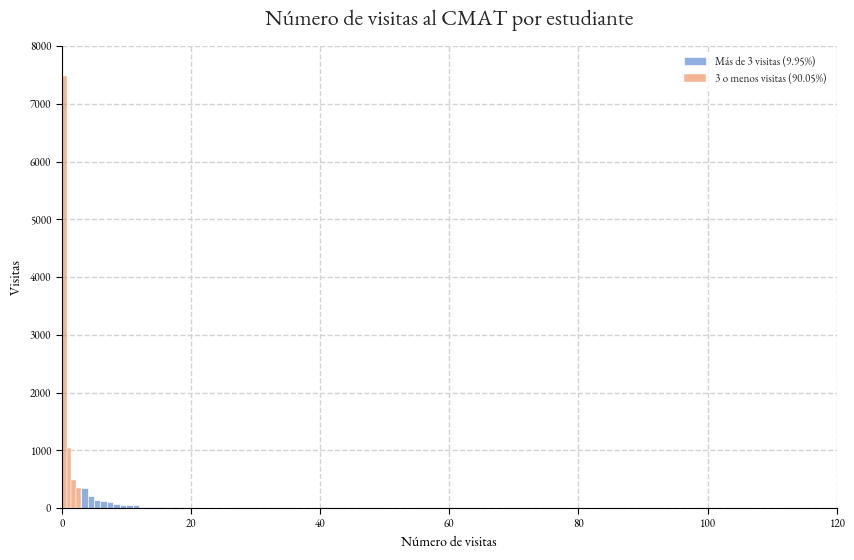

In [58]:
# density of VISITAS column
# count the percentage of students with more than 3 visits
plt.figure(figsize=(10, 6))
total_students = asesoria_counts.count()
num_more_than_3 = (asesoria_counts > 3).sum()
percentage_more_than_3 = (num_more_than_3 / total_students) * 100


sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label=f'Más de 3 visitas ({percentage_more_than_3:.2f}%)')
sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label=f'3 o menos visitas ({100-percentage_more_than_3:.2f}%)')
plt.title('Número de visitas al CMAT por estudiante')
plt.xlabel('Número de visitas')
plt.ylabel('Visitas')
plt.savefig('visualizations/nb_04reportes_raw/03_01.pdf', bbox_inches='tight')
plt.legend()

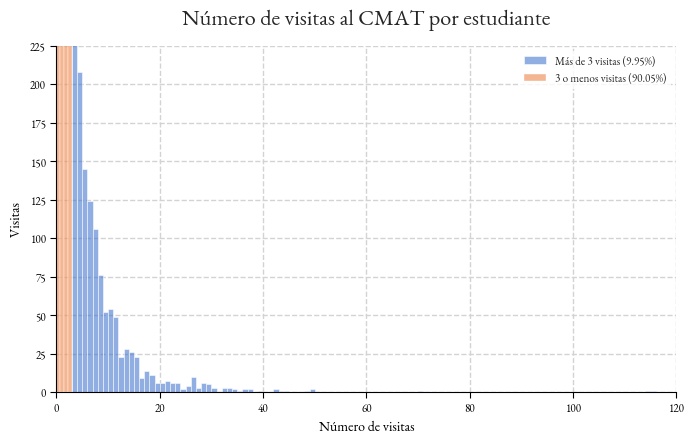

In [59]:
# density of VISITAS column
sns.histplot(asesoria_counts[asesoria_counts >= 3], bins=asesoria_counts.max()-3,  alpha=0.6, label=f'Más de 3 visitas ({percentage_more_than_3:.2f}%)')
sns.histplot(asesoria_counts[asesoria_counts <= 3], bins=4,  alpha=0.6, label=f'3 o menos visitas ({100-percentage_more_than_3:.2f}%)')
plt.title('Número de visitas al CMAT por estudiante')
plt.xlabel('Número de visitas')
plt.ylabel('Visitas')
plt.legend()
plt.ylim(0, 225)
plt.savefig('visualizations/nb_04reportes_raw/03_02.pdf', bbox_inches='tight')


In [60]:
# if the id of asesorias_counts is in materias['CLAVEALUMNO'], map the count to a new column 'VISITAS' in materias
materias['VISITAS'] = materias['CLAVEALUMNO'].map(asesoria_counts)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453,0
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897,0
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446,0
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149,0


In [61]:
materias[materias['CLAVEALUMNO'] == 175199]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
15962,175199,LAT,2021,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.1,23835,13
15963,175199,LAT,2022,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,10,23897,13
15964,175199,LAT,2022,OTOÑO,MAT1022,CÁLCULO I,10,24827,13
15965,175199,LAT,2023,PRIMAVERA,MAT2012,CÁLCULO II,10,23874,13


Agregamos las visitas registradas al CMAT por id

In [62]:
# add the timmes each id appears as a new column 'asesoria_count' in asesorias

materias['VISITAS'] = materias['VISITAS'].fillna(0).astype(int)
materias

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0
1,92988,LPA,2019,OTOÑO,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.6,21815,3
2,94286,LEF,2022,OTOÑO,MAT2092,ESTADÍSTICA PARA CIENCIAS DE LA SALUD,7.7,22109,3
3,111083,LFP,2024,PRIMAVERA,MAT1022,CÁLCULO I,10,24085,0
9,140079,LNA,2023,OTOÑO,MAT1022,CÁLCULO I,9.2,23152,49
...,...,...,...,...,...,...,...,...,...
26403,403107,INT,2019,OTOÑO,MAT1022,CÁLCULO I,8,23453,0
26413,403205,INT,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,8.5,23897,0
26546,403514,INT,2021,OTOÑO,MAT1022,CÁLCULO I,8.8,22446,0
26547,403514,INT,2022,PRIMAVERA,MAT2012,CÁLCULO II,8.1,23149,0


In [63]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

In [64]:
salones[(23453, 'MAT1012', 2020, 'PRIMAVERA')].head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0,5.355,-0.639014,3.906841,-1.026326
844,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.500000,-2.321189
3338,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.300000,-0.496818
3506,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.500000,0.339352
3572,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.800000,0.453375


# Comparacion Global

In [65]:
ultramerge = pd.concat(salones.values(), ignore_index=True)
ultramerge.head()

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0,5.355,-0.639014,3.906841,-1.026326
1,162163,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,0.5,23453,0,0.500,-2.745662,0.500000,-2.321189
2,164382,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,5.3,23453,0,5.300,-0.662880,5.300000,-0.496818
3,164516,LMK,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.5,23453,0,7.500,0.291729,7.500000,0.339352
4,164551,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,7.8,23453,0,7.800,0.421903,7.800000,0.453375


por promedio de calificaciones del estudiante

In [66]:
# get the mean of each CLAVEALUMNO in ultramerge
ultramerge_means = ultramerge.groupby('CLAVEALUMNO')['IMPKDE_Z'].mean().reset_index()
ultramerge_means.rename(columns={'IMPKDE_Z': 'MEAN_IMPKDE_Z'}, inplace=True)
ultramerge_means = ultramerge_means.merge(materias[['CLAVEALUMNO', 'VISITAS']].drop_duplicates(), on='CLAVEALUMNO', how='left')
ultramerge_means

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
0,88493,-1.026326,0
1,92988,1.596966,3
2,94286,-0.134400,3
3,111083,0.180808,0
4,140079,0.982520,49
...,...,...,...
10408,402894,0.724407,0
10409,403107,0.732535,0
10410,403205,-0.870484,0
10411,403514,0.603979,0


In [67]:
ultramerge_means

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
0,88493,-1.026326,0
1,92988,1.596966,3
2,94286,-0.134400,3
3,111083,0.180808,0
4,140079,0.982520,49
...,...,...,...
10408,402894,0.724407,0
10409,403107,0.732535,0
10410,403205,-0.870484,0
10411,403514,0.603979,0


In [68]:
# view the highest MEAN_IMPKDE_Z
ultramerge_means.sort_values(by='MEAN_IMPKDE_Z', ascending=False).head(10)

,CLAVEALUMNO,MEAN_IMPKDE_Z,VISITAS
8633,181475,2.819633,2
9680,184438,1.941437,0
9193,183171,1.941437,0
9722,184556,1.941437,0
8986,182532,1.898041,2
6836,177125,1.889346,0
4481,171487,1.877836,0
1199,163905,1.876713,2
9640,184349,1.842330,0
6898,177284,1.779363,0


In [69]:
ultramerge[ultramerge['CLAVEALUMNO'] == 181475]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
8811,181475,LPO,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9.9,22115,2,9.9,2.819633,9.9,2.819633


In [70]:
# ultramerge where CALIFICACION is not numeric
ultramerge[~pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce').notnull()]

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
0,88493,LCN,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,0,5.355,-0.639014,3.906841,-1.026326
9,166296,LIV,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,23453,1,5.355,-0.639014,2.636772,-1.509051
10,166299,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453,0,5.355,-0.639014,7.161663,0.210758
14,166485,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453,0,5.355,-0.639014,5.682025,-0.351619
18,167055,LAR,2020,PRIMAVERA,MAT1012,MATEMÁTICAS UNIVERSITARIAS,BV,23453,0,5.355,-0.639014,4.787357,-0.691662
...,...,...,...,...,...,...,...,...,...,...,...,...,...
26105,182207,LBN,2024,OTOÑO,MAT2012,CÁLCULO II,BV,25510,0,5.100,-2.872255,4.800000,-3.027911
26110,183220,LIS,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,25510,0,7.500,-1.390491,7.500000,-1.390491
26121,184039,LNI,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,25510,0,7.500,-1.390491,7.500000,-1.390491
26124,184376,LIM,2024,OTOÑO,MAT1012,MATEMÁTICAS UNIVERSITARIAS,RT,25510,0,7.500,-1.390491,7.500000,-1.390491


In [71]:
# replace them with NaN values
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

In [72]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
outlier
# IT IS CLA

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
11445,171250,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8,22115,0,8.0,-0.098742,8.0,-0.098742
18419,177578,LPM,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.8,22115,0,8.8,1.130048,8.8,1.130048
19590,178484,LEA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9,22115,0,9.0,1.437245,9.0,1.437245
20000,178914,LRP,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.4,22115,7,8.4,0.515653,8.4,0.515653
20402,179351,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.6,22115,1,7.6,-0.713137,7.6,-0.713137
20853,179782,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.8,22115,1,7.8,-0.405939,7.8,-0.405939
20908,179841,LPD,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,0,8.1,0.054857,8.1,0.054857
21092,180003,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,BV,22115,1,7.5,-0.866736,7.5,-0.866736
21214,180143,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,7,8.1,0.054857,8.1,0.054857
21372,180285,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.5,22115,2,8.5,0.669251,8.5,0.669251


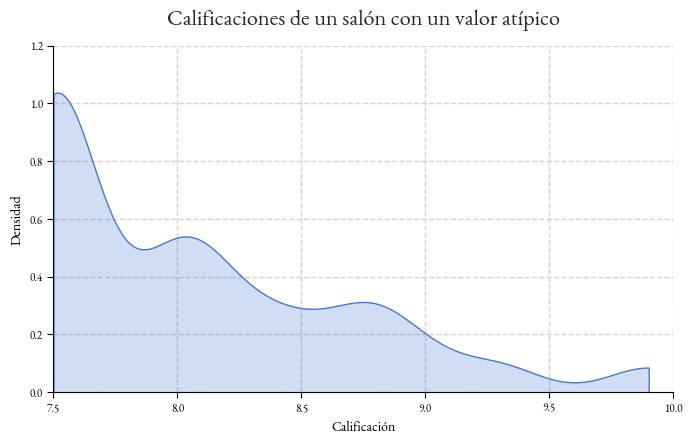

In [73]:
# plot impkde of outlier
sns.kdeplot(outlier['IMPKDE'], cut=0, bw_adjust=0.5, fill=True)
plt.title('Calificaciones de un salón con un valor atípico')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
plt.savefig('visualizations/nb_04reportes_raw/05_03.pdf', bbox_inches='tight')
plt.show()

# Esta mal la imputacion cuando no hay menos de 7.5!!! Corregir la imputacion

In [74]:


def _silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2: return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = min(sd, iqr/1.34) if iqr > 0 else sd
    h = 0.9 * s * n**(-1/5)
    return max(h, 1e-3)

def _sample_kde_truncated(x_obs, size, low=0.0, high=7.5, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    h = _silverman_bandwidth(x_obs)
    out = np.empty(size, dtype=float); k = 0
    while k < size:
        batch = size - k
        idx = rng.integers(0, len(x_obs), size=batch)
        eps = rng.normal(0.0, h, size=batch)
        draw = x_obs[idx] + eps
        ok = (draw >= low) & (draw <= high)
        take = min(ok.sum(), batch)
        if take:
            out[k:k+take] = draw[ok][:take]
            k += take
    return out

def _sample_empirical(x_obs, size, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    x_obs = np.asarray(x_obs, dtype=float)
    return rng.choice(x_obs, size=size, replace=True)

def impute_nans_from_pre75_kde_df(
    df, value_col='CALIFICACION', out_col='IMPKDE',
    low=0.0, high=7.4, min_kde_n=20, seed=42,
    fallback='uniform',           # 'constant' | 'global' | 'parametric' | 'leave' | 'uniform'
    constant_value=6.5,
    prefer_empirical_if_small=True,
    global_source=None,
    debug=False
):
    rng = np.random.default_rng(seed)
    df = df.copy()

    num = pd.to_numeric(df[value_col], errors='coerce')
    df[out_col] = num
    nan_mask = num.isna()
    need = int(nan_mask.sum())
    if need == 0:
        return df

    obs_pre = num[~num.isna() & (num <= high)]

    def _borrow_pool():
        src = pd.to_numeric(global_source, errors='coerce') if global_source is not None else num
        return src[(~src.isna()) & (src <= high)]

    if len(obs_pre) >= min_kde_n:
        draws = _sample_kde_truncated(obs_pre.values, need, low=low, high=high, rng=rng)
    elif 0 < len(obs_pre) < min_kde_n:
        draws = np.clip(_sample_empirical(obs_pre.values, need, rng=rng), low, high)
    else:
        # No mass in [low, high]; choose fallback
        if fallback == 'global':
            pool = _borrow_pool()
            if len(pool) >= min_kde_n:
                draws = _sample_kde_truncated(pool.values, need, low=low, high=high, rng=rng)
            elif len(pool) > 0:
                draws = np.clip(_sample_empirical(pool.values, need, rng=rng), low, high)
            else:
                draws = np.full(need, min(constant_value, high))
        elif fallback == 'parametric':
            obs_all = num[~num.isna()]
            mu = float(obs_all.mean()) if len(obs_all) else 6.5
            sd = float(obs_all.std(ddof=1)) if len(obs_all) > 1 else 0.5
            sd = max(sd, 1e-3)
            k, draws = 0, np.empty(need)
            while k < need:
                batch = need - k
                cand = rng.normal(mu, sd, size=batch)
                ok = (cand >= low) & (cand <= high)
                take = min(ok.sum(), batch)
                if take:
                    draws[k:k+take] = cand[ok][:take]
                    k += take
        elif fallback == 'uniform':
            # Equally spaced interior points in [low, high]
            # order matches the order of NaNs in the DataFrame
            ks = np.arange(1, need + 1, dtype=float)
            draws = low + (ks / (need + 1.0)) * (high - low)
        elif fallback == 'leave':
            return df
        elif fallback == 'constant':
            draws = np.full(need, min(constant_value, high))
        else:
            raise ValueError("Unknown fallback")

    df.loc[nan_mask, out_col] = draws
    # Clip through pandas so we do not depend on NumPy returning a writeable view.
    df.loc[nan_mask, out_col] = df.loc[nan_mask, out_col].clip(
        lower=low,
        upper=high,
    )
    return df


In [75]:
# make all the classrooms available
salones = {}

# for all the professors
# for all the CLAVEVARIANTEMATERIA in profe_materias
# for all the years
# create a dictionary of salones with keys as (CLAVEPROFESOR, CLAVEVARIANTEMATERIA, anio, CLAVESESION) and values as the corresponding dataframes
for prof_id in profes_ids:
    profe_materias = materias[materias['CLAVEPROFESOR'] == prof_id]
    for materia in profe_materias['CLAVEVARIANTEMATERIA'].unique():
        materia_materias = profe_materias[profe_materias['CLAVEVARIANTEMATERIA'] == materia]
        for anio in materia_materias['anio'].unique():
            anio_materias = materia_materias[materia_materias['anio'] == anio]
            for sesion in anio_materias['CLAVESESION'].unique():
                sesion_materias = anio_materias[anio_materias['CLAVESESION'] == sesion]
                # replace the non numeric calificaciones with the mean of the numeric calificaciones THAT ARE LESS THAN OR EQUAL TO 7.5
                numeric_calificaciones = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce')
                mean_calificacion = numeric_calificaciones[numeric_calificaciones <= 7.5].mean()
                sesion_materias['IMPMEAN'] = pd.to_numeric(sesion_materias['CALIFICACION'], errors='coerce').fillna(mean_calificacion)
                mean = sesion_materias['IMPMEAN'].mean()
                std = sesion_materias['IMPMEAN'].std()
                sesion_materias['IMPMEAN_Z'] = (sesion_materias['IMPMEAN'] - mean) / std
                sesion_materias = impute_nans_from_pre75_kde_df(
                    sesion_materias,
                    value_col='CALIFICACION',
                    out_col='IMPKDE', constant_value=6.5, fallback='uniform'
                )
                mean = sesion_materias['IMPKDE'].mean()
                std = sesion_materias['IMPKDE'].std()
                sesion_materias['IMPKDE_Z'] = (sesion_materias['IMPKDE'] - mean) / std
                salones[(prof_id, materia, anio, sesion)] = sesion_materias

In [76]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
outlier

,CLAVEALUMNO,CLAVECARRERA,anio,CLAVESESION,CLAVEVARIANTEMATERIA,DESCRIBEMATERIA,CALIFICACION,CLAVEPROFESOR,VISITAS,IMPMEAN,IMPMEAN_Z,IMPKDE,IMPKDE_Z
11445,171250,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8,22115,0,8.0,-0.098742,8.00,0.459688
18419,177578,LPM,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.8,22115,0,8.8,1.130048,8.80,0.777497
19590,178484,LEA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,9,22115,0,9.0,1.437245,9.00,0.856950
20000,178914,LRP,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.4,22115,7,8.4,0.515653,8.40,0.618593
20402,179351,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.6,22115,1,7.6,-0.713137,7.60,0.300784
20853,179782,LPA,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,7.8,22115,1,7.8,-0.405939,7.80,0.380236
20908,179841,LPD,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,0,8.1,0.054857,8.10,0.499414
21092,180003,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,BV,22115,1,7.5,-0.866736,0.74,-2.424430
21214,180143,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.1,22115,7,8.1,0.054857,8.10,0.499414
21372,180285,LRI,2024,PRIMAVERA,MAT1052,ESTADÍSTICA PARA CIENCIAS SOCIALES,8.5,22115,2,8.5,0.669251,8.50,0.658319


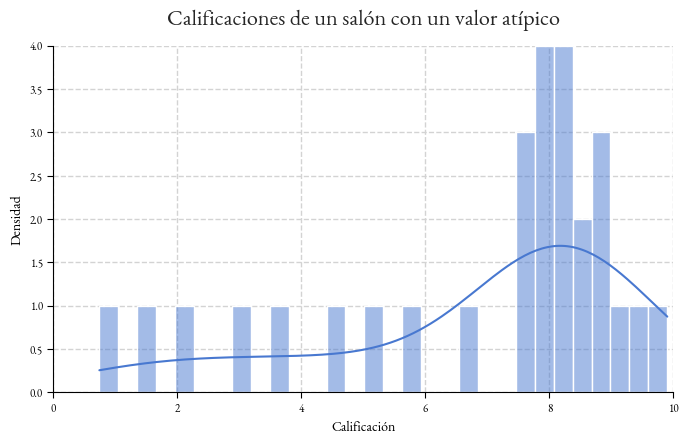

In [77]:
outlier = salones[(22115, 'MAT1052', 2024, 'PRIMAVERA')]
# plot impkde of outlier
sns.histplot(outlier['IMPKDE'], bins=30, kde=True)
plt.title('Calificaciones de un salón con un valor atípico')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.savefig('visualizations/profes_distributions/imputation/imputation_outlier.png', bbox_inches='tight')
plt.savefig('visualizations/nb_04reportes_raw/05_04.pdf', bbox_inches='tight')
plt.show()

In [78]:
ultramerge = pd.concat(salones.values(), ignore_index=True)
# replace them with NaN values
ultramerge['CALIFICACION'] = pd.to_numeric(ultramerge['CALIFICACION'], errors='coerce')

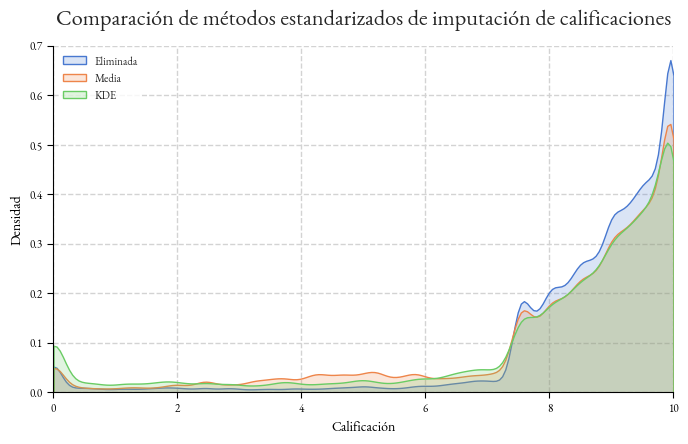

In [79]:
sns.kdeplot(ultramerge['CALIFICACION'], cut=0, bw_adjust=0.5, clip=(0, 10), fill=True, alpha=0.2, label='Eliminada')

sns.kdeplot(ultramerge['IMPMEAN'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='Media')

# z score the IMPKDE column
sns.kdeplot(ultramerge['IMPKDE'], cut=0, bw_adjust=0.5, fill=True, alpha=0.2, label='KDE')

# plot the second subplot: mean imputed z score

plt.title('Comparación de métodos estandarizados de imputación de calificaciones')
plt.xlabel('Calificación')
plt.ylabel('Densidad')
plt.legend()
plt.savefig('visualizations/profes_distributions/imputation/imputation_comparison_estandarizada.png', bbox_inches='tight')
plt.savefig('visualizations/nb_04reportes_raw/05_05.pdf', bbox_inches='tight')
plt.show()

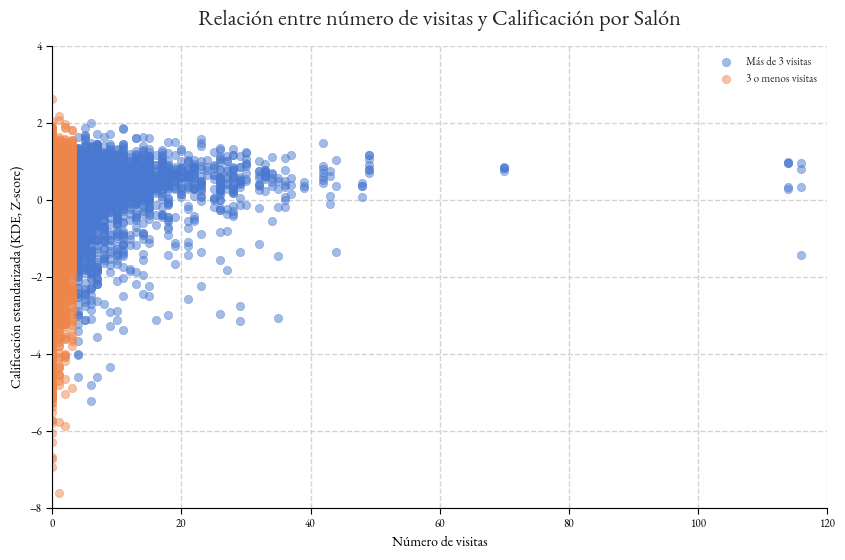

In [80]:
# get the students that have more than 3 visitas
group1 = ultramerge[ultramerge['VISITAS'] > 3]
group2 = ultramerge[ultramerge['VISITAS'] <= 3]

# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=group1, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=group2, x='VISITAS', y='IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)
plt.title('Relación entre número de visitas y Calificación por Salón')
plt.xlabel('Número de visitas')
plt.ylabel('Calificación estandarizada (KDE, Z-score)')
plt.legend()

plt.savefig('visualizations/nb_04reportes_raw/07_00.pdf', bbox_inches='tight')

plt.show()

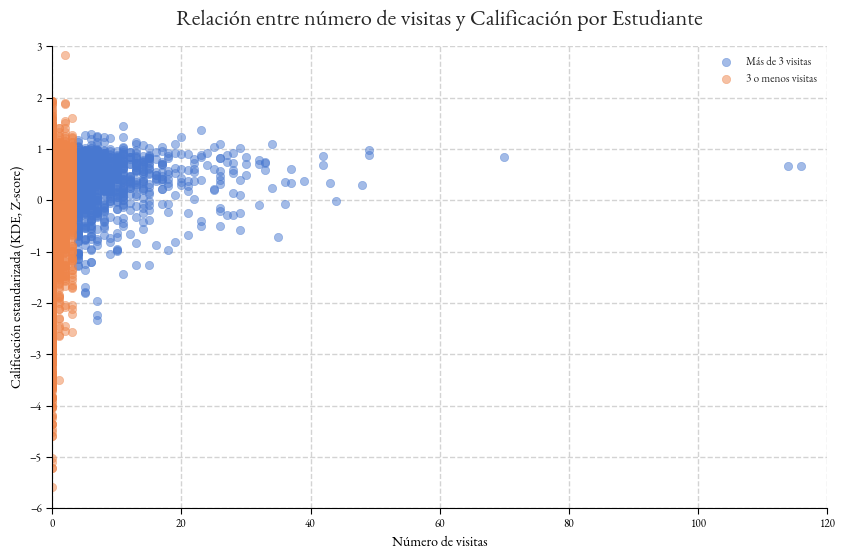

In [81]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)


plt.title('Relación entre número de visitas y Calificación por Estudiante')
plt.xlabel('Número de visitas')
plt.ylabel('Calificación estandarizada (KDE, Z-score)')
plt.legend()

plt.savefig('visualizations/nb_04reportes_raw/08_00.pdf', bbox_inches='tight')

plt.show()

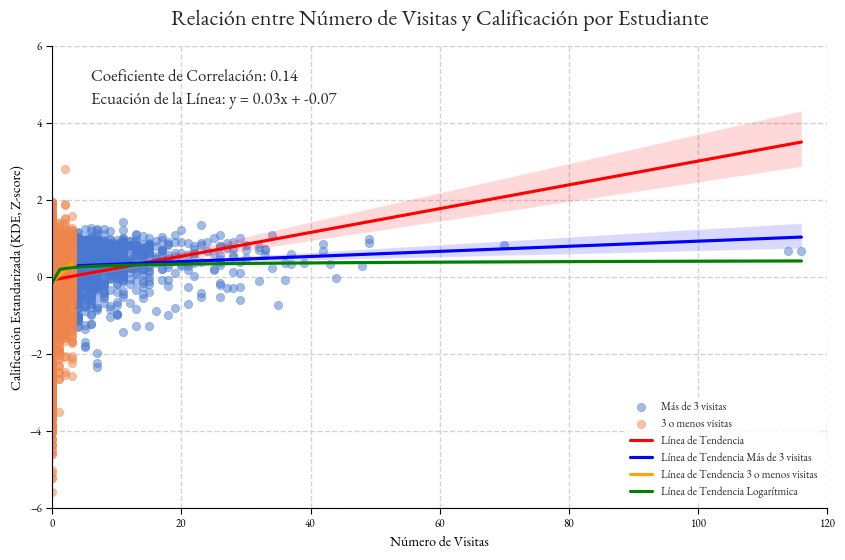

In [82]:
# SCATTERPLOT, x=VISITAS, y=IMPKDE_Z
plt.figure(figsize=(10, 6)) 
# remove the border of each point with sns.scatterplot
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='Más de 3 visitas', edgecolor=None)
sns.scatterplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', alpha=0.5, label='3 o menos visitas', edgecolor=None)

# add a regression line
sns.regplot(data=ultramerge_means, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='red', line_kws={'label':"Línea de Tendencia"}, label='Línea de Tendencia')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] > 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='blue', line_kws={'label':"Línea de Tendencia Más de 3 visitas"}, label='Línea de Tendencia Más de 3 visitas')
sns.regplot(data=ultramerge_means[ultramerge_means['VISITAS'] <= 3], x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='orange', line_kws={'label':"Línea de Tendencia 3 o menos visitas"}, label='Línea de Tendencia 3 o menos visitas')

# get the slope and intercept of the regression line
import statsmodels.api as sm
X = sm.add_constant(ultramerge_means['VISITAS'])
model = sm.OLS(ultramerge_means['MEAN_IMPKDE_Z'], X).fit()
slope = model.params['VISITAS']
intercept = model.params['const']
plt.text(0.05, 0.90, f'Ecuación de la Línea: y = {slope:.2f}x + {intercept:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')


# get the correlation coefficient
corr = ultramerge_means['VISITAS'].corr(ultramerge_means['MEAN_IMPKDE_Z'])
plt.text(0.05, 0.95, f'Coeficiente de Correlación: {corr:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

# it is like a logarithmic relationship
# change the 0 to 0.1 to avoid log(0)
ultramerge_logs = ultramerge_means.copy()
ultramerge_logs['VISITAS'] = ultramerge_logs['VISITAS'].replace(0, 0.001)
sns.regplot(data=ultramerge_logs, x='VISITAS', y='MEAN_IMPKDE_Z', scatter=False, color='green', line_kws={'label':"Línea de Tendencia Logarítmica"}, label='Línea de Tendencia Logarítmica', logx=True)

plt.title('Relación entre Número de Visitas y Calificación por Estudiante')
plt.xlabel('Número de Visitas')
plt.ylabel('Calificación Estandarizada (KDE, Z-score)')
plt.legend()
plt.show()

# Diferencia de medias

T-statistic: 21.92866612672149, P-value: 1.1407354865240441e-94


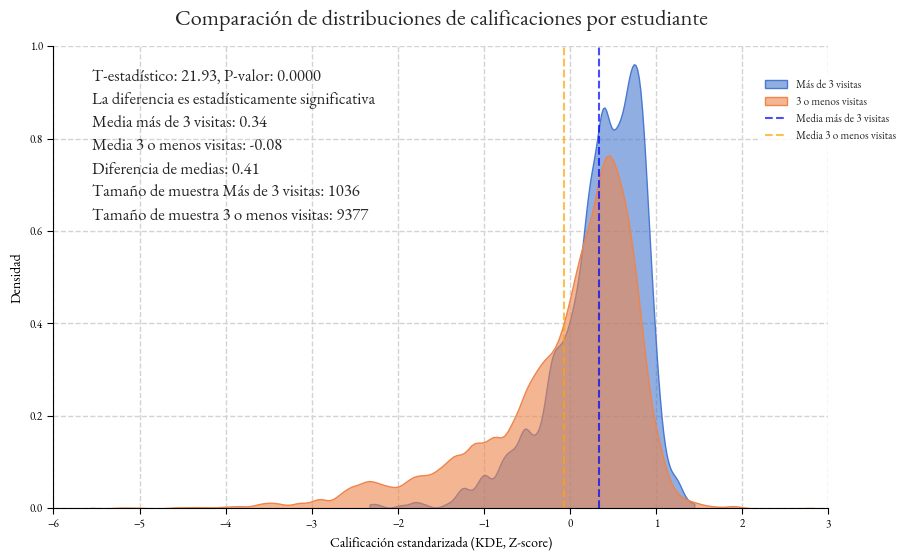

In [83]:
# compare the zscore of each group and test the difference of means

group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z']
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z']
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de distribuciones de calificaciones por estudiante')
plt.xlabel('Calificación estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

plt.text(0.05, 0.95, f'T-estadístico: {t_stat:.2f}, P-valor: {p_value:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
# if p_value < 0.05, add a note that the difference is statistically significant
if p_value < 0.05:
    plt.text(0.05, 0.90, 'La diferencia es estadísticamente significativa', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.85, f'Media más de 3 visitas: {group1.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.80, f'Media 3 o menos visitas: {group2.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.75, f'Diferencia de medias: {group1.mean() - group2.mean():.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.70, f'Tamaño de muestra Más de 3 visitas: {len(group1)}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
    plt.text(0.05, 0.65, f'Tamaño de muestra 3 o menos visitas: {len(group2)}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')    

plt.vlines(x=group1.mean(), ymin=0, ymax=1, colors='blue', linestyles='--', label='Media más de 3 visitas', alpha=0.7)
plt.vlines(x=group2.mean(), ymin=0, ymax=1, colors='orange', linestyles='--', label='Media 3 o menos visitas', alpha=0.7)
# legend top right but outside the plot
plt.legend(loc='upper right', bbox_to_anchor=(1.1, .95))

plt.savefig('visualizations/nb_04reportes_raw/08_01.pdf', bbox_inches='tight')
plt.show()

T-statistic: 24.33805733639584, P-value: 1.6523873661729466e-124


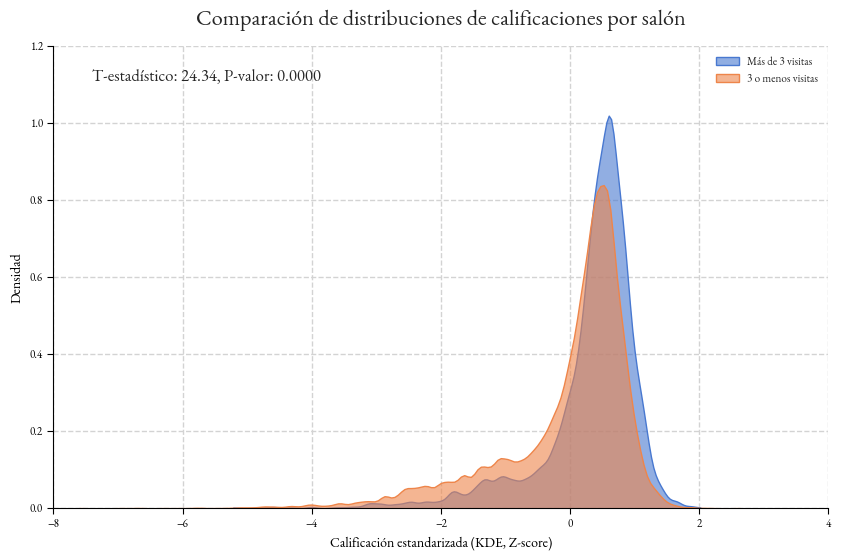

In [84]:
# compare the zscore of each group and test the difference of means
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z']
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z']
t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
print(f'T-statistic: {t_stat}, P-value: {p_value}')
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')
plt.title('Comparación de distribuciones de calificaciones por salón')
plt.xlabel('Calificación estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')
plt.legend()
plt.text(0.05, 0.95, f'T-estadístico: {t_stat:.2f}, P-valor: {p_value:.4f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.savefig('visualizations/nb_04reportes_raw/07_01.pdf', bbox_inches='tight')
plt.show()

# Metodos no parametricos

In [85]:


# Split groups
group1 = ultramerge_means[ultramerge_means['VISITAS'] > 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge_means[ultramerge_means['VISITAS'] <= 3]['MEAN_IMPKDE_Z'].dropna().to_numpy()
n1, n2 = len(group1), len(group2)

# 1) Mann–Whitney U (Wilcoxon rank-sum)
U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
U_star = max(U, n1*n2 - U)                       # for CL
CL = U_star / (n1*n2)                            # common-language effect size
r_rb = 2*CL - 1                                  # rank-biserial correlation

# 2) Brunner–Munzel
bm_stat, p_bm = stats.brunnermunzel(group1, group2, alternative='two-sided')

# 3) Robust median shift with bootstrap CI
def bootstrap_diff_median(x, y, B=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(B, float)
    n1, n2 = len(x), len(y)
    for b in range(B):
        xb = rng.choice(x, n1, replace=True)
        yb = rng.choice(y, n2, replace=True)
        diffs[b] = np.median(xb) - np.median(yb)
    ci = np.quantile(diffs, [0.025, 0.975])
    return np.median(x) - np.median(y), ci, diffs

dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=8000, seed=42)

# 4) Permutation test on the median difference
def stat_median(x, y):
    return np.median(x) - np.median(y)

perm = stats.permutation_test((group1, group2), stat_median,
                              n_resamples=5000, alternative='two-sided',
                              random_state=42)
p_perm_med = perm.pvalue

# 5) Cliff's delta (approx if very large)
def cliffs_delta(x, y, max_pairs=5_000_000, seed=0):
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    rng = np.random.default_rng(seed)
    if n1*n2 > max_pairs:
        m = int(np.sqrt(max_pairs))
        X = x[rng.integers(0, n1, m)]
        Y = y[rng.integers(0, n2, m)]
    else:
        X, Y = x, y
    cmp = X[:, None] - Y[None, :]
    gt = np.sum(cmp > 0)
    lt = np.sum(cmp < 0)
    return (gt - lt) / (X.size * Y.size)

delta = cliffs_delta(group1, group2)


In [86]:
def bootstrap_ci_two_sample(x, y, stat_fn, B=5000, seed=0, alpha=0.05):
    """
    Generic bootstrap CI for a two-sample statistic.

    x, y      : 1D arrays
    stat_fn   : function taking (x, y) and returning a scalar
    B         : number of bootstrap resamples
    alpha     : 1 - CI level (0.05 -> 95% CI)
    """
    rng = np.random.default_rng(seed)
    x = np.asarray(x)
    y = np.asarray(y)
    n1, n2 = len(x), len(y)

    boot_stats = np.empty(B, float)
    for b in range(B):
        xb = rng.choice(x, n1, replace=True)
        yb = rng.choice(y, n2, replace=True)
        boot_stats[b] = stat_fn(xb, yb)

    lower, upper = np.quantile(boot_stats, [alpha/2, 1 - alpha/2])
    return (lower, upper), boot_stats


In [87]:
U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
U_star = max(U, n1*n2 - U)                       # for CL
CL = U_star / (n1*n2)                            # common-language effect size
r_rb = 2*CL - 1                                  # rank-biserial correlation


In [88]:
def stat_CL(x, y):
    n1, n2 = len(x), len(y)
    U, _ = stats.mannwhitneyu(x, y, alternative='two-sided', method='auto')
    U_star = max(U, n1*n2 - U)
    CL = U_star / (n1*n2)
    return CL

# Bootstrap CI for CL
ci_CL, _ = bootstrap_ci_two_sample(group1, group2, stat_CL, B=4000, seed=123)

# From CL we derive r_rb, so we can bootstrap it directly as well:
def stat_r_rb(x, y):
    cl = stat_CL(x, y)
    return 2*cl - 1

ci_r_rb, _ = bootstrap_ci_two_sample(group1, group2, stat_r_rb, B=4000, seed=123)


In [89]:
def stat_delta(x, y):
    return cliffs_delta(x, y)

ci_delta, _ = bootstrap_ci_two_sample(group1, group2, stat_delta, B=400, seed=456)


In [90]:
dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=800, seed=42)


In [91]:
def stat_median_diff(x, y):
    return np.median(x) - np.median(y)

ci_med2, diffs = bootstrap_ci_two_sample(group1, group2, stat_median_diff, B=800, seed=42)
dmed2 = stat_median_diff(group1, group2)


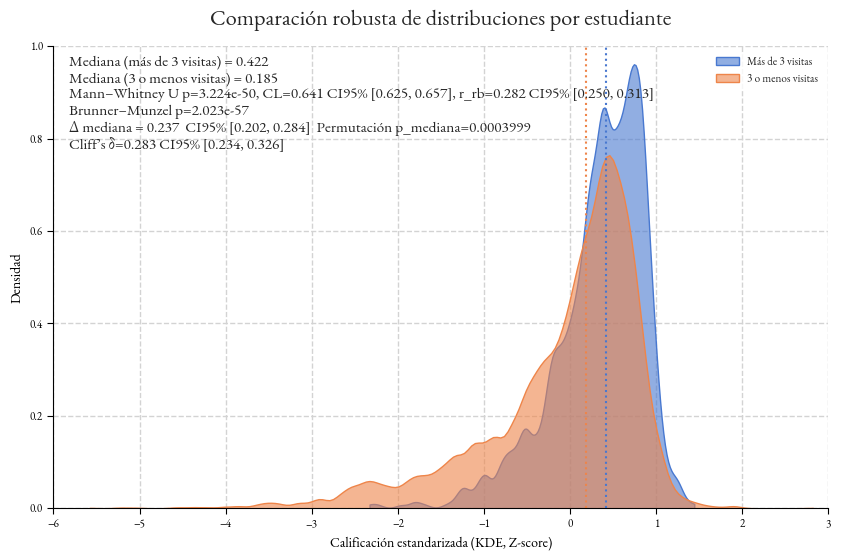

In [92]:

# ---- Plot with medians and robust stats
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')

m1, m2 = np.median(group1), np.median(group2)
plt.vlines([m1, m2], ymin=0, ymax=plt.gca().get_ylim()[1], colors=['C0','C1'],
           linestyles=':', linewidth=1.5)
plt.title('Comparación robusta de distribuciones por estudiante')
plt.xlabel('Calificación estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

text1 = (
    f"Mediana (más de 3 visitas) = {m1:.3f}\n"
    f"Mediana (3 o menos visitas) = {m2:.3f}\n"
    f"Mann–Whitney U p={p_mw:.4g}, CL={CL:.3f}, r_rb={r_rb:.3f}\n"
    f"Brunner–Munzel p={p_bm:.4g}\n"
    f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
    f"Permutación p_mediana={p_perm_med:.4g}\n"
    f"Cliff’s δ={delta:.3f}"
)

text = (
    f"Mediana (más de 3 visitas) = {m1:.3f}\n"
    f"Mediana (3 o menos visitas) = {m2:.3f}\n"
    f"Mann–Whitney U p={p_mw:.4g}, "
    f"CL={CL:.3f} CI95% [{ci_CL[0]:.3f}, {ci_CL[1]:.3f}], "
    f"r_rb={r_rb:.3f} CI95% [{ci_r_rb[0]:.3f}, {ci_r_rb[1]:.3f}]\n"
    f"Brunner–Munzel p={p_bm:.4g}\n"
    f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
    f"Permutación p_mediana={p_perm_med:.4g}\n"
    f"Cliff’s δ={delta:.3f} CI95% [{ci_delta[0]:.3f}, {ci_delta[1]:.3f}]"
)


plt.text(0.02, 0.98, text, transform=plt.gca().transAxes, va='top', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.savefig('visualizations/nb_04reportes_raw/08_02.pdf', bbox_inches='tight')
plt.show()


In [93]:
text

'Mediana (más de 3 visitas) = 0.422\nMediana (3 o menos visitas) = 0.185\nMann–Whitney U p=3.224e-50, CL=0.641 CI95% [0.625, 0.657], r_rb=0.282 CI95% [0.250, 0.313]\nBrunner–Munzel p=2.023e-57\nΔ mediana = 0.237  CI95% [0.202, 0.284]  Permutación p_mediana=0.0003999\nCliff’s δ=0.283 CI95% [0.234, 0.326]'

Evidence of a real but moderate shift upward for VISITAS>3.

**Interpretation**

* **Direction:** Group >3 has higher location. Median shift (\Delta_{50} = 0.237) (in your Z units). CI(_{95%}) ([0.204, 0.281]) excludes 0.
* **Stochastic dominance:** Mann–Whitney (p=3.2\times10^{-50}); Brunner–Munzel (p=2.0\times10^{-57}). Very small (p) due to large (n); focus on effect sizes.
* **Magnitude:** Common-language (CL=0.641) ⇒ a random obs. from VISITAS>3 exceeds one from ≤3 **64.1%** of the time.
  Rank-biserial (r_{rb}=0.282) and Cliff’s (\delta=0.283) both indicate a **small-to-moderate** effect.
  Normal-approx conversion (d\approx \sqrt{2},\Phi^{-1}(CL)\approx 0.52) (medium).
* **Robustness:** Permutation test on the median (p=4.0\times10^{-4}) aligns with ranks.

**Reporting text (concise)**
“Relative to ≤3 visitas, the >3 group shows higher scores: median difference (0.237) [0.204, 0.281]. Mann–Whitney (p<10^{-49}), Brunner–Munzel (p<10^{-56}), probability-of-superiority (0.641), Cliff’s (\delta=0.283). Results are consistent under a permutation test on the median.”

**Checks before finalizing**

* Independence and consistent measurement across groups.
* Ties: if heavy, note exact vs asymptotic method.
* Unequal spreads: cite BM as primary.
* Multiple comparisons: adjust if you run many tests.
* Add the Hodges–Lehmann shift (pseudo-median) for MWU if desired.

**Actionable add-ons**

* Plot a **quantile shift function** to show where the differences concentrate.
* Report (n_1,n_2), median(IQR) per group, and the above effect sizes.

[
\boxed{\text{Effect size: }CL=0.641;\Rightarrow;r_{rb}=2CL-1=0.282;\approx;d;0.52;;\Delta_{50}=0.237;[0.204,0.281]}
]


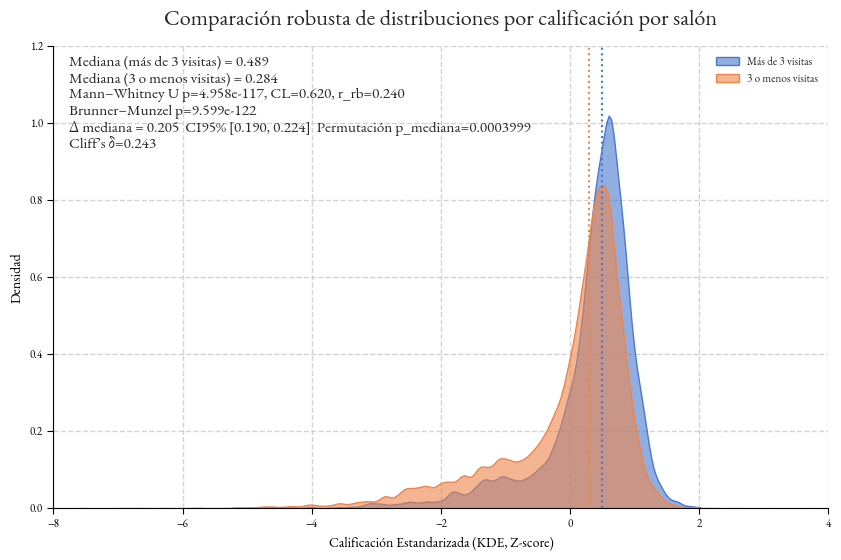

In [94]:
# Split groups
group1 = ultramerge[ultramerge['VISITAS'] > 3]['IMPKDE_Z'].dropna().to_numpy()
group2 = ultramerge[ultramerge['VISITAS'] <= 3]['IMPKDE_Z'].dropna().to_numpy()
n1, n2 = len(group1), len(group2)

# 1) Mann–Whitney U (Wilcoxon rank-sum)
U, p_mw = stats.mannwhitneyu(group1, group2, alternative='two-sided', method='auto')
U_star = max(U, n1*n2 - U)                       # for CL
CL = U_star / (n1*n2)                            # common-language effect size
r_rb = 2*CL - 1                                  # rank-biserial correlation

# 2) Brunner–Munzel
bm_stat, p_bm = stats.brunnermunzel(group1, group2, alternative='two-sided')

# 3) Robust median shift with bootstrap CI
def bootstrap_diff_median(x, y, B=10000, seed=0):
    rng = np.random.default_rng(seed)
    diffs = np.empty(B, float)
    n1, n2 = len(x), len(y)
    for b in range(B):
        xb = rng.choice(x, n1, replace=True)
        yb = rng.choice(y, n2, replace=True)
        diffs[b] = np.median(xb) - np.median(yb)
    ci = np.quantile(diffs, [0.025, 0.975])
    return np.median(x) - np.median(y), ci, diffs

dmed, ci_med, _ = bootstrap_diff_median(group1, group2, B=8000, seed=42)

# 4) Permutation test on the median difference
def stat_median(x, y):
    return np.median(x) - np.median(y)

perm = stats.permutation_test((group1, group2), stat_median,
                              n_resamples=5000, alternative='two-sided',
                              random_state=42)
p_perm_med = perm.pvalue

# 5) Cliff's delta (approx if very large)
def cliffs_delta(x, y, max_pairs=5_000_000, seed=0):
    """
    The cliff's delta effect size measure, if the number of pairs is too large, it uses a random sample.
    """
    x = np.asarray(x); y = np.asarray(y)
    n1, n2 = len(x), len(y)
    rng = np.random.default_rng(seed)
    if n1*n2 > max_pairs:
        m = int(np.sqrt(max_pairs))
        X = x[rng.integers(0, n1, m)]
        Y = y[rng.integers(0, n2, m)]
    else:
        X, Y = x, y
    cmp = X[:, None] - Y[None, :]
    gt = np.sum(cmp > 0)
    lt = np.sum(cmp < 0)
    return (gt - lt) / (X.size * Y.size)

delta = cliffs_delta(group1, group2)

# ---- Plot with medians and robust stats
plt.figure(figsize=(10, 6))
sns.kdeplot(group1, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='Más de 3 visitas')
sns.kdeplot(group2, cut=0, bw_adjust=0.5, fill=True, alpha=0.6, label='3 o menos visitas')

m1, m2 = np.median(group1), np.median(group2)
plt.vlines([m1, m2], ymin=0, ymax=plt.gca().get_ylim()[1], colors=['C0','C1'],
           linestyles=':', linewidth=1.5)
plt.title('Comparación robusta de distribuciones por calificación por salón')
plt.xlabel('Calificación Estandarizada (KDE, Z-score)')
plt.ylabel('Densidad')

text = (
    f"Mediana (más de 3 visitas) = {m1:.3f}\n"
    f"Mediana (3 o menos visitas) = {m2:.3f}\n"
    f"Mann–Whitney U p={p_mw:.4g}, CL={CL:.3f}, r_rb={r_rb:.3f}\n"
    f"Brunner–Munzel p={p_bm:.4g}\n"
    f"Δ mediana = {dmed:.3f}  CI95% [{ci_med[0]:.3f}, {ci_med[1]:.3f}]  "
    f"Permutación p_mediana={p_perm_med:.4g}\n"
    f"Cliff’s δ={delta:.3f}"
)
plt.text(0.02, 0.98, text, transform=plt.gca().transAxes, va='top', fontsize=11)
plt.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))

plt.savefig('visualizations/nb_04reportes_raw/07_02.pdf', bbox_inches='tight')
plt.show()


# Z promedio por estudiatne

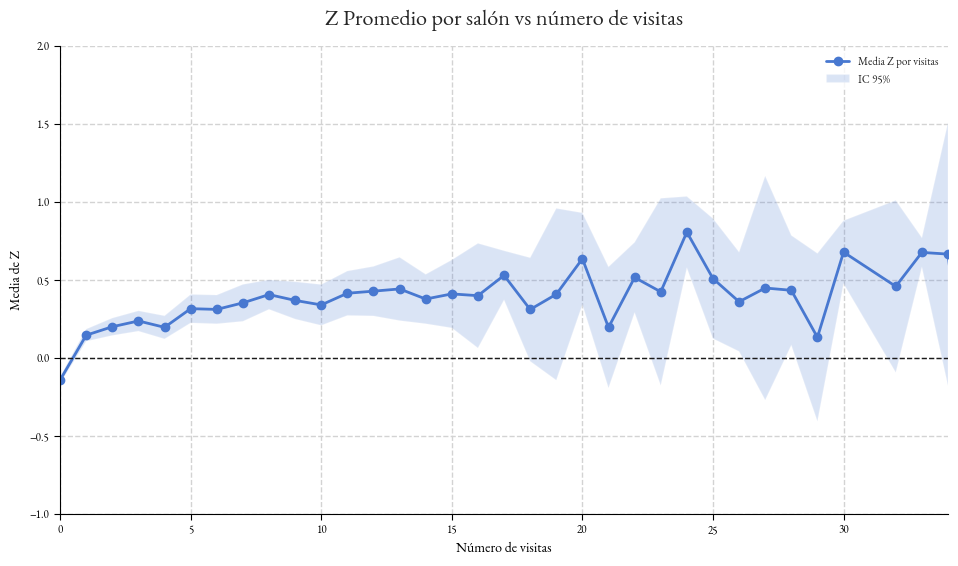

In [95]:
# agrupa por VISITAS y calcula media y error estándar
df = ultramerge_means[['VISITAS','MEAN_IMPKDE_Z']].dropna().copy()
agg = df.groupby('VISITAS')['MEAN_IMPKDE_Z'].agg(['mean','count','std'])
agg['se'] = agg['std'] / np.sqrt(agg['count'])
# intervalo de confianza 95% aproximado
agg['lo'] = agg['mean'] - 1.96*agg['se']
agg['hi'] = agg['mean'] + 1.96*agg['se']

plt.figure(figsize=(10,6))
plt.plot(agg.index, agg['mean'], marker='o', linewidth=2, label='Media Z por visitas')
plt.fill_between(agg.index, agg['lo'], agg['hi'], alpha=0.2, label='IC 95%')
plt.axhline(0, color='k', linewidth=1, linestyle='--')
plt.xlabel('Número de visitas')
plt.ylabel('Media de Z')
plt.title('Z Promedio por salón vs número de visitas')
plt.legend()
plt.tight_layout()
plt.xlim(0, 34)

plt.savefig('visualizations/nb_04reportes_raw/09_01.pdf', bbox_inches='tight')
plt.show()


# Maravillo plot 2

# Ver la diferencia en distribuciones (KDE y Dropping) por profesores agrupados por KS

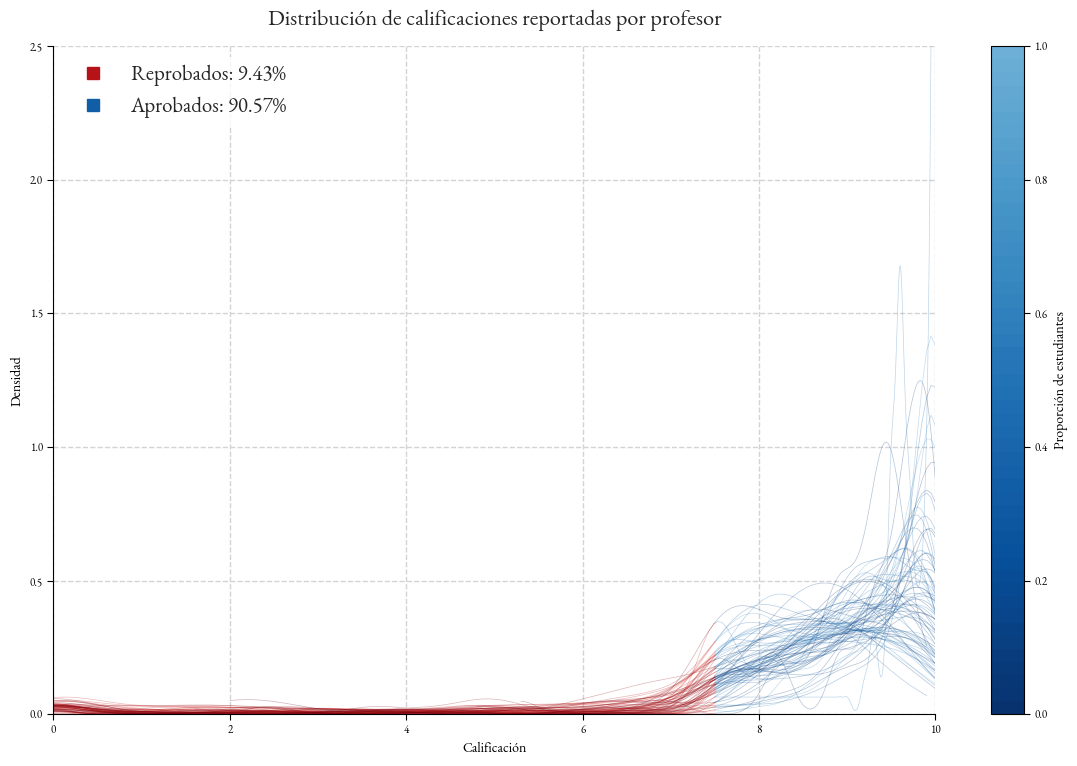

In [96]:
fig, ax = plt.subplots(figsize=(12, 8))

for num, prof_id in enumerate(profes_ids):
    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['CALIFICACION'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['CALIFICACION'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de calificaciones reportadas por profesor')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad')

students_without_calification=ultramerge['CALIFICACION'].isna().sum()

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

ax.set_xlim(0, 10)
ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de estudiantes')

plt.tight_layout()

plt.savefig('visualizations/nb_04reportes_raw/05_06.pdf', bbox_inches='tight')
plt.show()

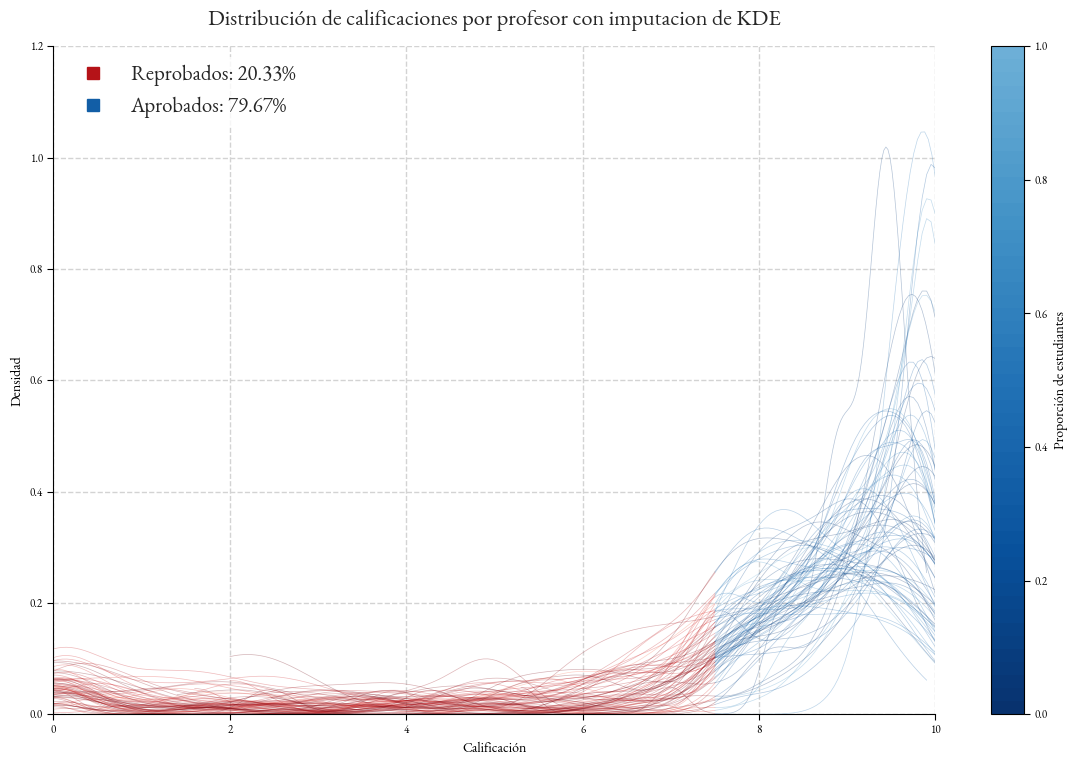

In [97]:
fig, ax = plt.subplots(figsize=(12, 8))

for num, prof_id in enumerate(profes_ids):
    profe2 = ultramerge[ultramerge['CLAVEPROFESOR'] == prof_id]
    profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
    if profe2num.empty:
        continue

    # draw KDE invisibly to obtain its sampled x,y from seaborn
    sns.kdeplot(
        profe2num['IMPKDE'],
        cut=0, bw_adjust=0.5, clip=(0, 10),
        color='none', linewidth=0, ax=ax
    )
    x, y = ax.lines[-1].get_data()
    ax.lines[-1].remove()  # remove the invisible line

    # ensure x is strictly increasing for interpolation safety
    order = np.argsort(x)
    x, y = x[order], y[order]

    # interpolate y at the split point to avoid a visual gap
    y_thr = np.interp(threshold, x, y)

    # left segment: x <= threshold
    mask_left = x <= threshold
    x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

    # right segment: x >= threshold
    mask_right = x >= threshold
    x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

    # plot two-tone KDE
    ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
    ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


# cosmetics
ax.set_title('Distribución de calificaciones por profesor con imputacion de KDE')
ax.set_xlabel('Calificación')
ax.set_ylabel('Densidad')

# combine existing legend entries with two custom entries for the means
handles, labels = ax.get_legend_handles_labels()
stat_handles = [
    Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
    Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
]

mean_below = (ultramerge['IMPKDE'] < threshold).mean()
mean_above = (ultramerge['IMPKDE'] >= threshold).mean()
stat_labels = [
    f'Reprobados: {mean_below:.2%}',
    f'Aprobados: {mean_above:.2%}'
]
ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

ax.set_xlim(0, 10)
#  ax.set_ylim(0, 2.5)

# add a colorbar only with the range of
# use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

half_palette = sns.color_palette("Blues_r", 100)[:51]
half_cmap = ListedColormap(half_palette)

sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Proporción de estudiantes')

plt.tight_layout()

plt.savefig('visualizations/nb_04reportes_raw/05_07.pdf', bbox_inches='tight')
plt.show()

# KS cluster para agrupar profesores por similitud en distribucion de calificaciones

In [98]:
# 0) isolate valid data and enforce support
df = ultramerge[['CLAVEPROFESOR','IMPKDE']].copy()
df['IMPKDE'] = pd.to_numeric(df['IMPKDE'], errors='coerce')
df = df.dropna(subset=['IMPKDE'])
df['IMPKDE'] = df['IMPKDE'].clip(0, 10)

# 1) keep professors with enough observations
nmin = 25  # adjust
counts = df.groupby('CLAVEPROFESOR').size()
keep = counts[counts >= nmin].index
df = df[df['CLAVEPROFESOR'].isin(keep)]
prof_ids = keep.to_list()

# 2) compute pairwise KS effect sizes, group by professor and store values in a dict
groups = {k: v.values for k, v in df.groupby('CLAVEPROFESOR')['IMPKDE']}
m = len(prof_ids)
D = np.zeros((m, m), dtype=float)

for a in range(m):
    xa = groups[prof_ids[a]]
    for b in range(a+1, m):
        xb = groups[prof_ids[b]]
        ks_stat, _ = stats.ks_2samp(xa, xb, alternative='two-sided', method='auto')
        D[a, b] = D[b, a] = ks_stat  # distance in [0,1]
# diagonal already zeros



In [99]:

# this in a dataframe for convenience
D_df = pd.DataFrame(D, index=prof_ids, columns=prof_ids)

c:\Users\herie\.conda\envs\cmat\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
c:\Users\herie\.conda\envs\cmat\Lib\site-packages\seaborn\matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


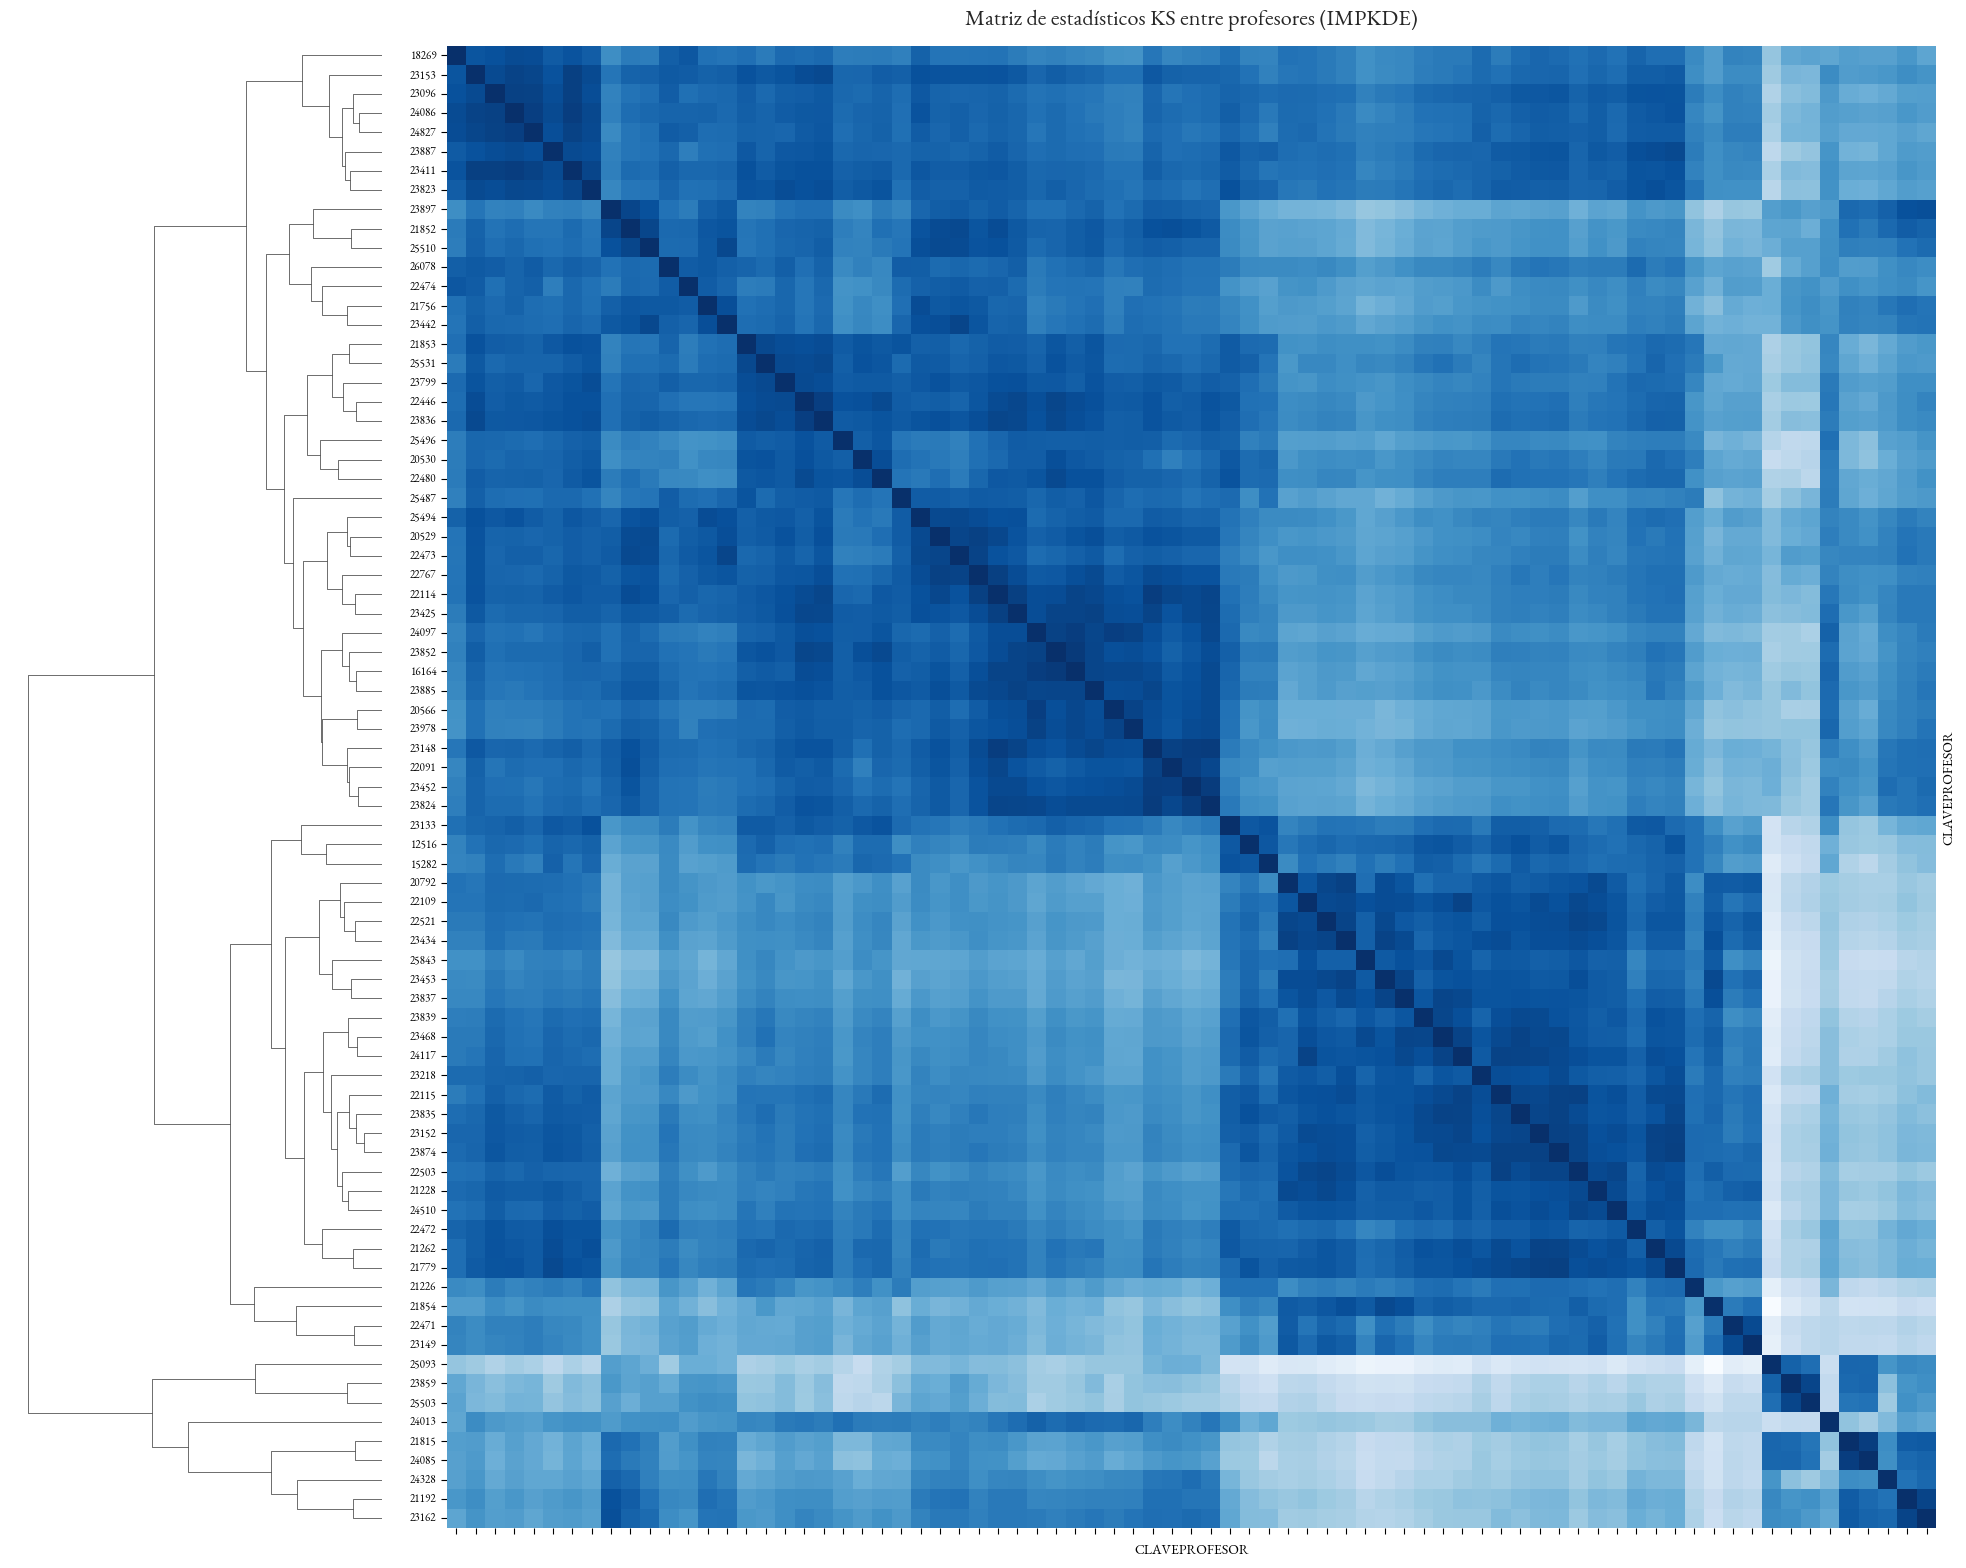

In [100]:
# plot the ks_matrix as a clustermap heatmap
# seaborn.clustermap creates its own figure and colorbar; capture the returned ClusterGrid

g = sns.clustermap(D_df, cmap='Blues_r', annot=False, figsize=(20, 20), xticklabels=True, yticklabels=True)

# set titles/labels on the heatmap axis
g.ax_heatmap.set_title('Matriz de estadísticos KS entre profesores (IMPKDE)')
g.ax_heatmap.set_xlabel('CLAVEPROFESOR')
g.ax_heatmap.set_ylabel('CLAVEPROFESOR')

# rotate tick labels and set small font
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=8)
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)

# set colorbar label using the clustergrid's cax (colorbar axis)
# if hasattr(g, 'cax') and g.cax is not None:
# hide colorbar
if hasattr(g, 'cax') and g.cax is not None:
    g.cax.set_visible(False)
	
# hide the top cluster dendrogram
g.ax_col_dendrogram.set_visible(False)

# move the labels from right side to left side
g.ax_heatmap.yaxis.set_label_position("right")
g.ax_heatmap.yaxis.tick_left()
g.ax_heatmap.yaxis.set_ticks_position("left")

# dont show x tick labels 
g.ax_heatmap.xaxis.set_ticklabels([])

plt.tight_layout()

plt.savefig('visualizations/nb_04reportes_raw/05_08.pdf', bbox_inches='tight')
plt.show()

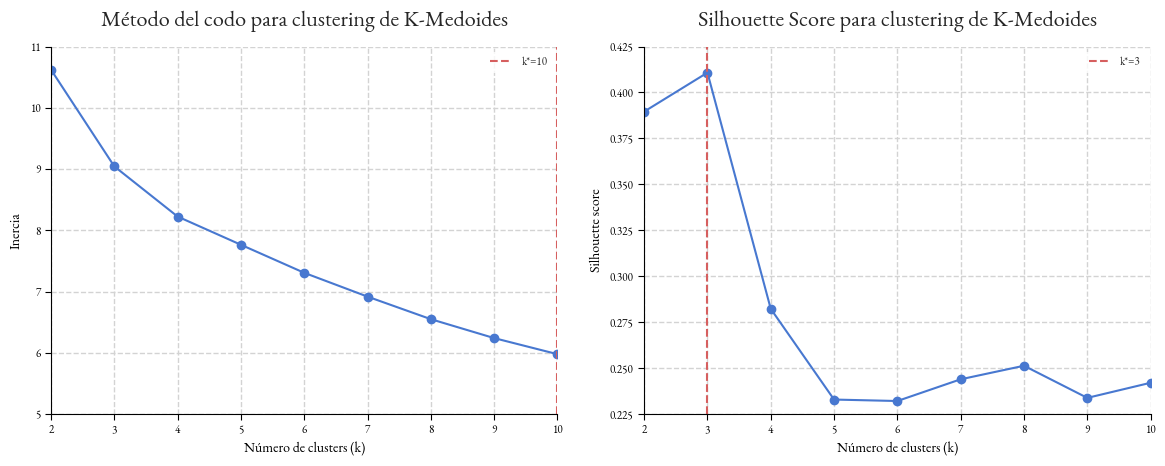

In [101]:
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

ks = range(2, 11)
elbow, sils = [], []

for k in ks:
    best_inertia, best_labels = np.inf, None
    for seed in range(20):
        km = KMedoids(n_clusters=k, metric='precomputed', method='pam',
                      init='k-medoids++', random_state=seed)
        km.fit(D)
        if km.inertia_ < best_inertia:
            best_inertia = km.inertia_
            best_labels  = km.labels_
    elbow.append(best_inertia)
    sils.append(silhouette_score(D, best_labels, metric='precomputed'))

k_star_elbow = ks[int(np.argmin(np.gradient(np.gradient(elbow))))]  # knee by curvature
k_star_sil   = ks[int(np.argmax(sils))]


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)    
plt.plot(ks, elbow, marker='o')
plt.axvline(k_star_elbow, color='r', linestyle='--', label=f'k*={k_star_elbow}')
plt.title('Método del codo para clustering de K-Medoides')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.legend()
plt.subplot(1, 2, 2)    
plt.plot(ks, sils, marker='o')
plt.axvline(k_star_sil, color='r', linestyle='--', label=f'k*={k_star_sil}')
plt.title('Silhouette Score para clustering de K-Medoides')  
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette score')
plt.legend()
plt.tight_layout()

plt.savefig('visualizations/nb_04reportes_raw/05_09.pdf', bbox_inches='tight')
plt.show()

Silhouette measures **cluster separation vs. cohesion** on a per-point basis and averages it.

**Glossary**

(d(x,y)): distance.
(C(i)): cluster containing point (i).
(a(i)): mean distance from (i) to points in (C(i)) (intra-cluster).
(b(i)): minimum, over all other clusters $C\neq C(i)$, of the mean distance from (i) to (C) (nearest other cluster).
(s(i)): silhouette of (i).
$\bar s$: mean silhouette over all points.

**Definition**

For each point (i):
$$
a(i)=\frac{1}{|C(i)|-1}\sum_{j\in C(i) j\neq i} d(i j) \qquad
b(i)=\min_{C\neq C(i)}\frac{1}{|C|}\sum_{j\in C} d(i j).
$$
$$
\boxed{ s(i)=\frac{b(i)-a(i)}{\max{a(i) b(i)}}\in[-1,1],}
$$
Aggregate with $\bar s=\frac{1}{n}\sum_i s(i)$.

**Interpretation**

* $s(i)\approx 1$: well inside its cluster far from others.
* $s(i)\approx 0$: on a boundary between clusters.
* $s(i)<0$: closer to another cluster than to its own → likely misassigned.
* $\bar s$ compares different (k): larger is better but it typically declines as (k) increases because clusters get tighter but also closer.

**For your plot**

* Distance is the **KS effect size (D)**. Using `metric='precomputed'` is valid.
* The right panel says the cleanest global separation occurs at $k=2$ $(\bar s\approx0.5)$.
* For $k\ge4$ the silhouettes flatten at $\approx0.27!-!0.31$: clusters exist but are **overlapping**.
* Combine with the elbow: choose the **smallest (k)** past the inertia knee that still keeps $\bar s$ acceptable. Here that argues for $k=2$ or $k=3$ unless domain reasons require finer strata.

**Practical checks**

* Inspect the **distribution of (s(i))** by cluster. Low-median clusters are weak or too small.
* Validate stability by bootstrapping prefer (k) with high median (s(i)) and stable medoids.
* If distances are non-metric or noisy also report **Wasserstein** or **energy distance** silhouettes for sensitivity.

> “What is not measured is not managed.” — often attributed to Drucker.
$$
\boxed{\bar s(k)=\frac{1}{n}\sum_i\frac{b(i)-a(i)}{\max{a(i) b(i)}},\ \text{pick }k\text{ maximizing }\bar s\text{ subject to an inertia knee}}
$$


# Distribuciones de calificaciones de profesores por clusters

In [102]:
# cluster with k=4
kmedoids = KMedoids(n_clusters=3, random_state=42)
kmedoids.fit(D_df.to_numpy())
ultramerge['KS_CLUSTER'] = ultramerge['CLAVEPROFESOR'].map(
    dict(zip(D_df.index, kmedoids.labels_))
)

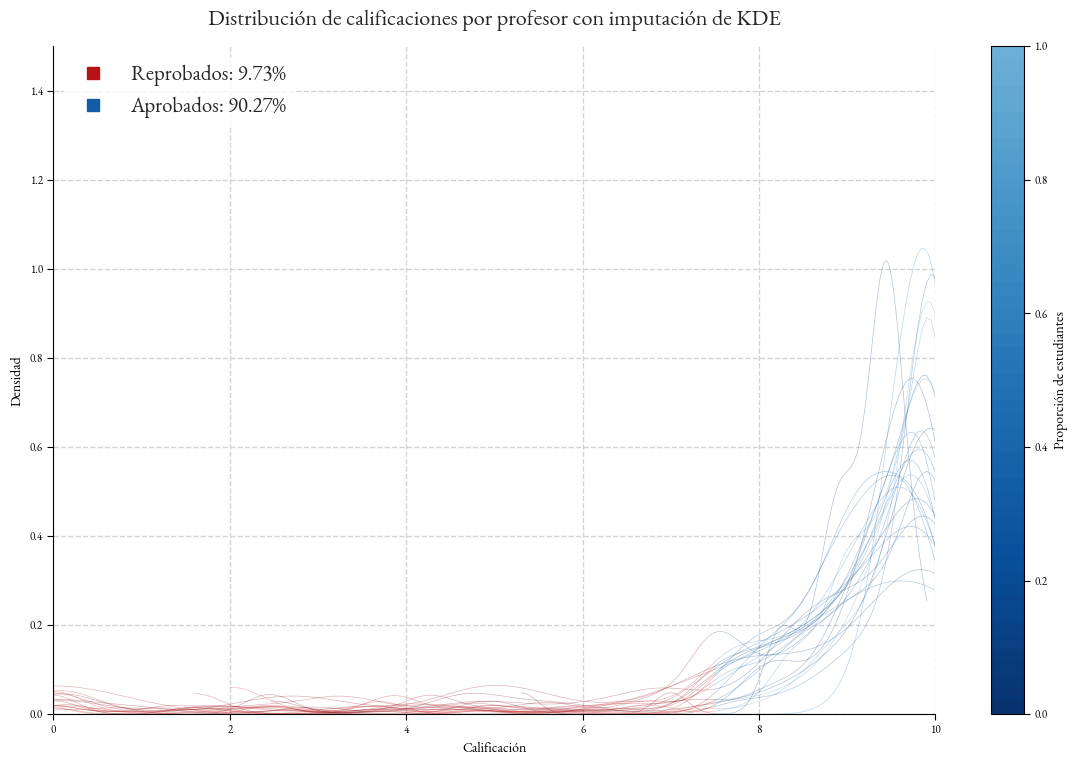

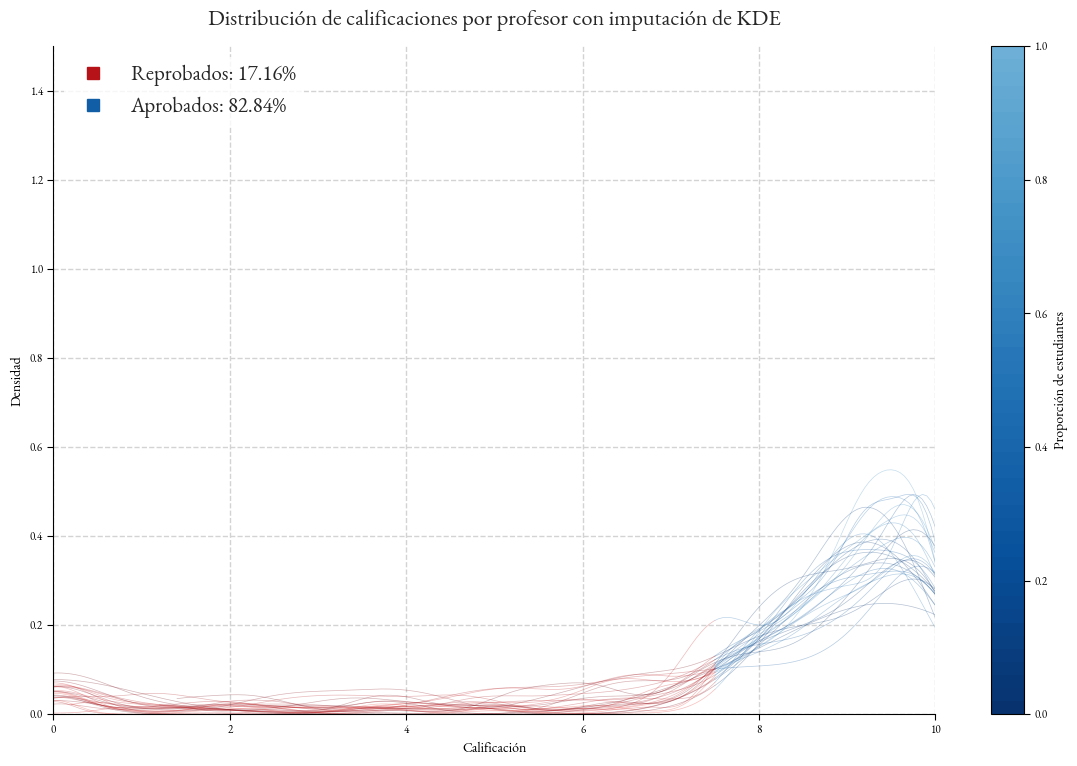

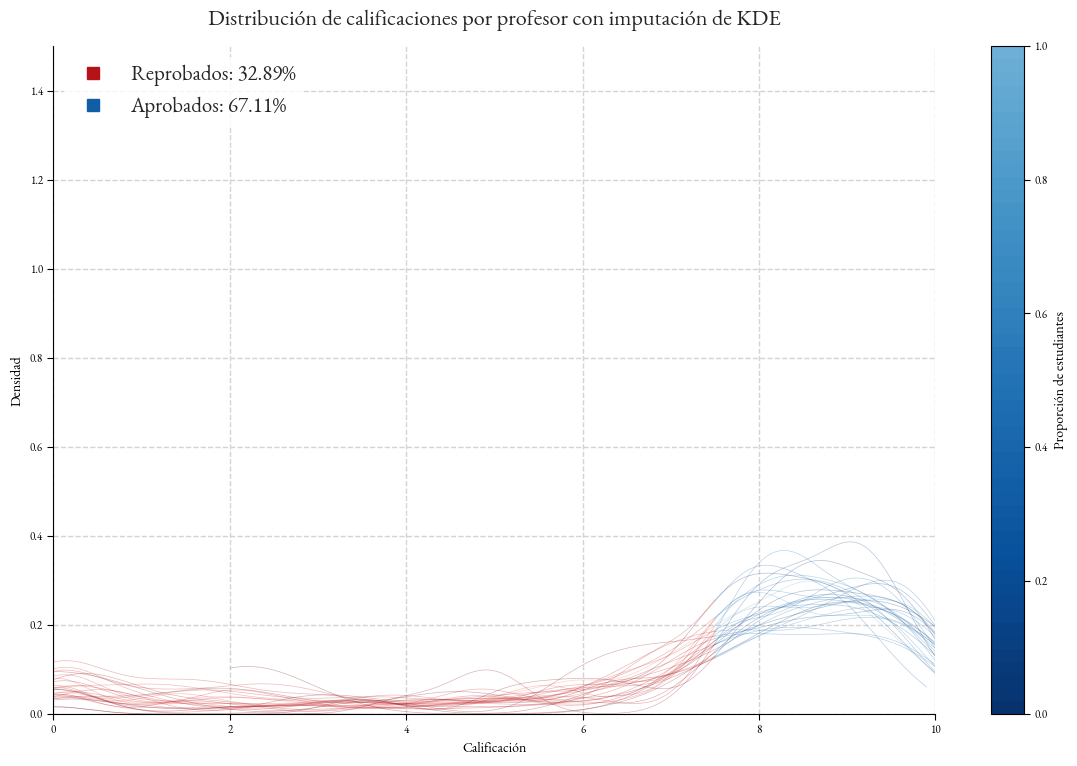

In [103]:
for i in range(3):

    fig, ax = plt.subplots(figsize=(12, 8))

    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]
        if profe2num.empty:
            continue

        # draw KDE invisibly to obtain its sampled x,y from seaborn
        sns.kdeplot(
            profe2num['IMPKDE'],
            cut=0, bw_adjust=0.5, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()  # remove the invisible line

        # ensure x is strictly increasing for interpolation safety
        order = np.argsort(x)
        x, y = x[order], y[order]

        # interpolate y at the split point to avoid a visual gap
        y_thr = np.interp(threshold, x, y)

        # left segment: x <= threshold
        mask_left = x <= threshold
        x_left, y_left = np.append(x[mask_left], threshold), np.append(y[mask_left], y_thr)

        # right segment: x >= threshold
        mask_right = x >= threshold
        x_right, y_right = np.insert(x[mask_right], 0, threshold), np.insert(y[mask_right], 0, y_thr)

        # plot two-tone KDE
        ax.plot(x_left,  y_left,  color=magma_by_prof[num], linewidth=0.5, alpha=0.3)
        ax.plot(x_right, y_right, color=viridis_by_prof[num], linewidth=0.5, alpha=0.3)  # put legend label on one segment only


    # cosmetics
    ax.set_title('Distribución de calificaciones por profesor con imputación de KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad')

    # combine existing legend entries with two custom entries for the means
    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [
        f'Reprobados: {mean_below:.2%}',
        f'Aprobados: {mean_above:.2%}'
    ]
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    # add a colorbar only with the range of
    # use the same "half" Blues_r palette you used for viridis_by_prof/magma_by_prof
    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)

    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Proporción de estudiantes')

    plt.tight_layout()
    plt.savefig(f'visualizations/nb_04reportes_raw/05_10_{i}.pdf', bbox_inches='tight')
    plt.show()

# Distribuciones con intervalos de confianza por clusters de profesores

In [104]:
SQRT_2PI = np.sqrt(2*np.pi)

def silverman_bandwidth(x):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 2:
        return 0.1
    sd = np.std(x, ddof=1)
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    s = sd if iqr <= 0 else min(sd, iqr/1.34)
    return 0.9 * s * n**(-1/5)

def kde_gaussian_grid(x_grid, sample, h):
    # x_grid: (m,), sample: (n,), returns f_hat(x_grid): (m,)
    Z = (x_grid[:, None] - sample[None, :]) / h        # (m,n)
    return np.exp(-0.5 * Z**2).sum(axis=1) / (len(sample) * h * SQRT_2PI)

def kde_bootstrap_ci(x_grid, sample, h, B=200, q=(2.5, 97.5), rng=None):
    rng = np.random.default_rng(None if rng is None else rng)
    n = len(sample)
    m = len(x_grid)
    boot = np.empty((B, m), dtype=float)
    idx = np.arange(n)
    for b in range(B):
        resample = sample[rng.integers(0, n, n)]
        boot[b] = kde_gaussian_grid(x_grid, resample, h)
    lo, hi = np.percentile(boot, q, axis=0)
    return lo, hi


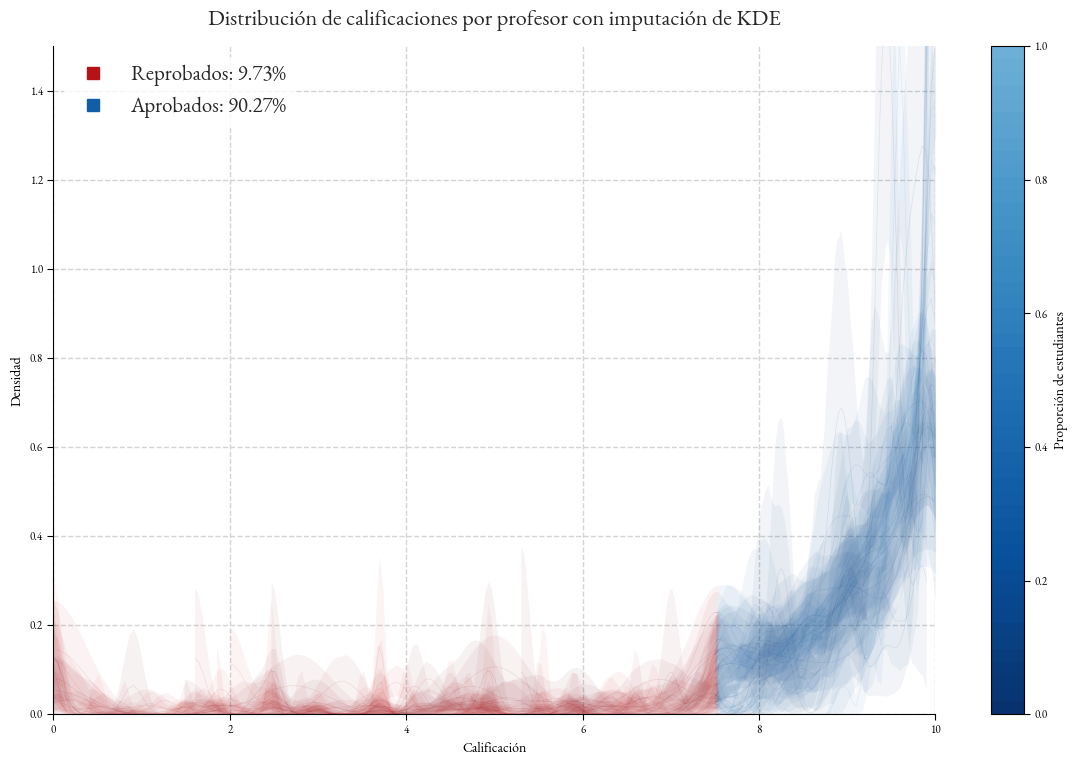

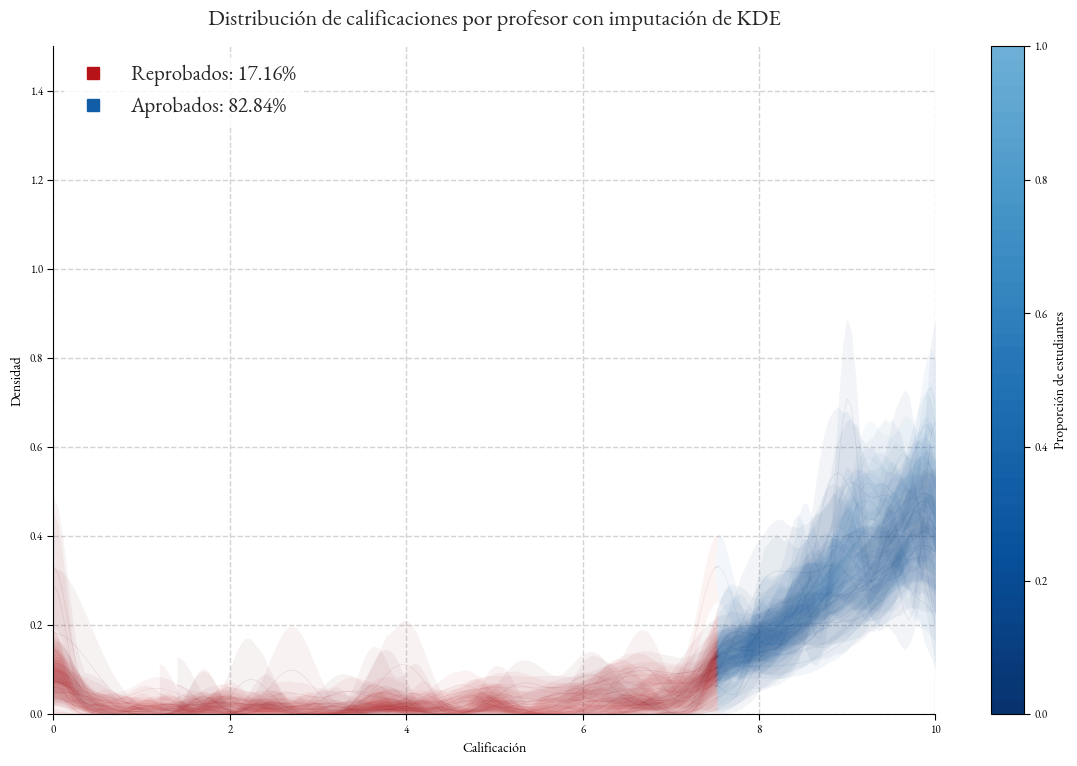

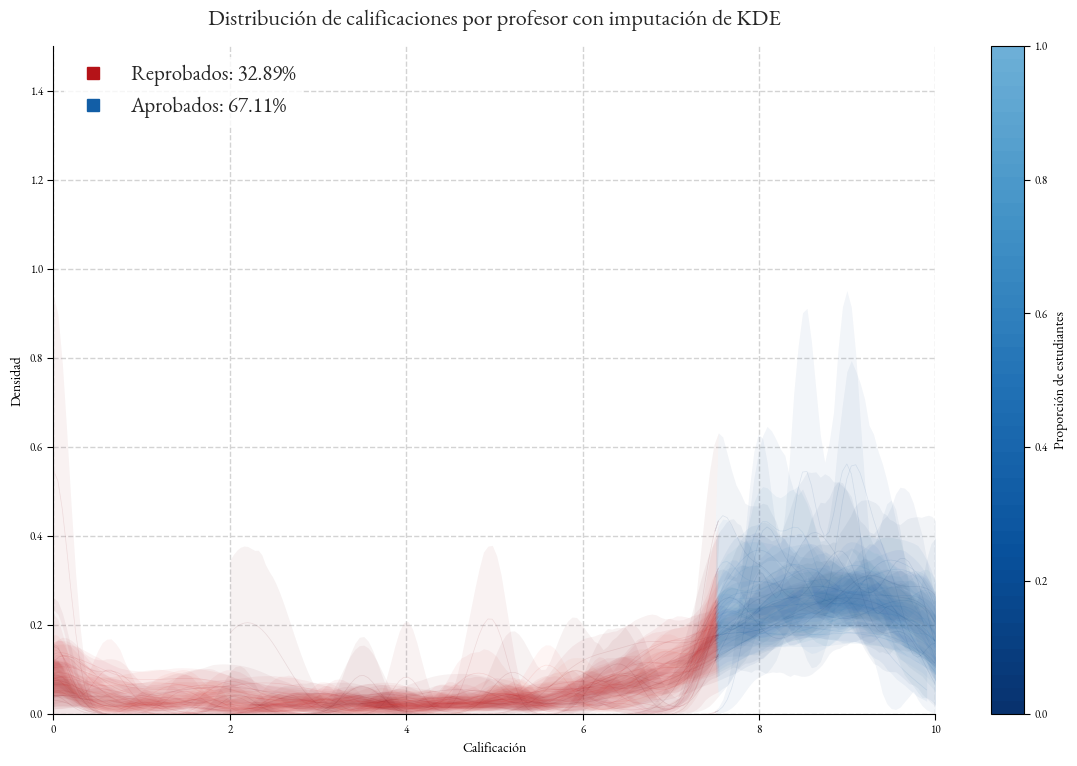

In [105]:
for i in range(3):
    fig, ax = plt.subplots(figsize=(12, 8))
    k1 = ultramerge[ultramerge['KS_CLUSTER'] == i]

    bw_adj = 0.5
    B = 200          # bootstrap replicates
    alpha_line = 0.1
    alpha_band = 0.05

    for num, prof_id in enumerate(profes_ids):
        profe2 = k1[k1['CLAVEPROFESOR'] == prof_id]
        profe2num = profe2[pd.to_numeric(profe2['IMPKDE'], errors='coerce').notnull()]['IMPKDE'].to_numpy(float)
        if profe2num.size == 0:
            continue

        # draw KDE invisibly to obtain seaborn's grid
        sns.kdeplot(
            profe2num, cut=0, bw_adjust=bw_adj, clip=(0, 10),
            color='none', linewidth=0, ax=ax
        )
        x, y = ax.lines[-1].get_data()
        ax.lines[-1].remove()

        # ensure sorted grid
        order = np.argsort(x)
        x, y = x[order], y[order]

        # bandwidth: Silverman * bw_adjust on this professor's data
        h = silverman_bandwidth(profe2num) * bw_adj
        # point estimate on the same grid (to match CI computation exactly)
        y_hat = kde_gaussian_grid(x, profe2num, h)

        # bootstrap CIs at each x
        lo, hi = kde_bootstrap_ci(x, profe2num, h, B=B, q=(2.5, 97.5), rng=42)

        # split at threshold
        y_thr = np.interp(threshold, x, y_hat)

        mask_left = x <= threshold + 0.06
        mask_right = x >= threshold

        # close the split so bands do not gap
        x_left  = np.append(x[mask_left],  threshold)
        yh_left = np.append(y_hat[mask_left], y_thr)
        lo_left = np.append(lo[mask_left],   y_thr)  # conservative join
        hi_left = np.append(hi[mask_left],   y_thr)

        x_right  = np.insert(x[mask_right],  0, threshold)
        yh_right = np.insert(y_hat[mask_right], 0, y_thr)
        lo_right = np.insert(lo[mask_right],   0, y_thr)
        hi_right = np.insert(hi[mask_right],   0, y_thr)

        # plot bands first, then lines
        ax.fill_between(x_left,  lo_left,  hi_left,
                        color=magma_by_prof[num], alpha=alpha_band, linewidth=0)
        ax.fill_between(x_right, lo_right, hi_right,
                        color=viridis_by_prof[num], alpha=alpha_band, linewidth=0)

        ax.plot(x_left,  yh_left,  color=magma_by_prof[num],  linewidth=0.5, alpha=alpha_line)
        ax.plot(x_right, yh_right, color=viridis_by_prof[num], linewidth=0.5, alpha=alpha_line)

    # cosmetics unchanged
    ax.set_title('Distribución de calificaciones por profesor con imputación de KDE')
    ax.set_xlabel('Calificación')
    ax.set_ylabel('Densidad')

    handles, labels = ax.get_legend_handles_labels()
    stat_handles = [
        Line2D([0], [0], marker='s', color=magma_by_prof[35], markersize=8, linestyle=''),
        Line2D([0], [0], marker='s', color=viridis_by_prof[35], markersize=8, linestyle='')
    ]
    mean_below = (k1['IMPKDE'] < threshold).mean()
    mean_above = (k1['IMPKDE'] >= threshold).mean()
    stat_labels = [f'Reprobados: {mean_below:.2%}', f'Aprobados: {mean_above:.2%}']
    ax.legend(handles + stat_handles, labels + stat_labels, loc='upper left', fontsize='small')

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 1.5)

    half_palette = sns.color_palette("Blues_r", 100)[:51]
    half_cmap = ListedColormap(half_palette)
    sm = plt.cm.ScalarMappable(cmap=half_cmap, norm=plt.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Proporción de estudiantes')

    plt.tight_layout()
    plt.savefig(f'visualizations/nb_04reportes_raw/05_11_{i}.pdf', bbox_inches='tight')
    plt.show()


Sí. Aquí tienes el texto listo para tu informe. Ajusta solo los valores que dejes marcados si luego quieres añadir métricas de sensibilidad.

### Imputación de faltantes por KDE truncado

**Magnitud del faltante.** En la variable **CALIFICACION** se observaron (3{,}217) valores faltantes sobre (26{,}140) registros ((12.30

**Mecanismo de ausencia.** Los faltantes no son aleatorios (**MNAR**): corresponden a estudiantes con baja académica. Bajo MNAR, el análisis por listas completas es sesgado; por ello imputamos para mitigar sesgo de selección y conservar potencia.

**Soporte y criterio de truncación.** Restringimos el soporte a $[\ell h]=[0,,7.5]$. Este rango coincide con la muestra operativa por salón para estudiantes no aprobados y recoge heterogeneidad de calificación por salón y periodo.

**Método de imputación.** Aplicamos **imputación única** basada en un **KDE truncado** ajustado con los valores observados (\mathcal O={x_i:\ x_i\le 7.5,\ x_i\ \text{no es NaN}}). Para cada faltante $X_i$ se genera un pseudo-valor por “jitter” de la forma
$$
X_i^{\text{imp}} \sim \left[\frac{1}{n_o}\sum_{j=1}^{n_o}\mathcal N(x_j h_S^2)\right]\ \Big|\ 0\le X_i^{\text{imp}}\le 7.5,
$$
donde $n_o=|\mathcal O|$ y $h_S$ es el ancho de banda.

**Selección del ancho de banda.** Usamos la **regla de Silverman** implementada así:
$$
h_S = 0.9 s n_o^{-1/5} \qquad
s=\min\ (\hat\sigma,\ \frac{\mathrm{IQR}}{1.34}),
$$
con tope inferior técnico $h_S\ge 10^{-3}$. Aquí $\hat\sigma$ es la desviación estándar muestral y $\mathrm{IQR}=P_{75}-P_{25}$ sobre $\mathcal O$.
Cuando $n_o<20$ se recurre a una **muestra empírica con reemplazo** sobre $\mathcal O$ y se recorta al rango ([0,7.5]). Si $n_o=0$ se usa un valor constante de reserva $c=6.5\le 7.5$.

**Detalles de implementación.** Semilla reproducible `seed=42` con generador `PCG64` muestreo por rechazo a partir de índices aleatorios sobre $\mathcal O$ y ruidos $\varepsilon\sim\mathcal N(0,h_S^2)$ los valores observados permanecen **intocados** y solo se imputan las celdas originalmente NaN.

**Diagnóstico posterior recomendado.**
i) Comparar observados vs imputados en **media varianza y cuantiles** $(P_{10},P_{50},P_{90})$.
ii) Medir distancia KS o energy distance entre ambas distribuciones.
iii) Análisis de **sensibilidad** variando la semilla y escalando $h_S$ en $\pm 10
iv) Si el objetivo es inferencial, repetir con **imputación múltiple** $m\ge 5$ y combinar con **reglas de Rubin** para reflejar la incertidumbre por imputación.

**Resumen operativo.** Faltantes $=3{,}217/26{,}140$ (MNAR). Imputación por KDE truncado en ([0,7.5]) con **Silverman** $(h_S=0.9 s n_o^{-1/5})$; conmutación a muestreo empírico si $n_o<20$ y a constante (6.5) si $n_o=0$; semilla 42; solo se modifican NaNs; se recomienda validar con KS/distancias y, para inferencia, usar imputación múltiple.


We construct **pointwise bootstrap confidence intervals** for each professor’s KDE. Below is the complete method.

### 0) Glossary

* Sample $x_{1:n}$: observed values of `IMPKDE` for one professor.
* KDE $\hat f_h(x)$: kernel density estimator with bandwidth (h).
* Bandwidth (h): smoothing scale; we use Silverman’s rule multiplied by your `bw_adjust`.
* Grid ${x_j}_{j=1}^m$: x-locations where we evaluate the KDE; we reuse seaborn’s grid.
* Bootstrap replicate: a KDE computed on a **resample with replacement** of size (n).
* Pointwise CI at $x_j$: interval covering $\hat f(x_j)$ with nominal probability $1-\alpha$.

> “Resample your way to certainty, then admit the uncertainty.” — anonymous

### 1) Problem and notation

Given sample $x_{1:n}\in[0,10]$, kernel $K(u)=\tfrac{1}{\sqrt{2\pi}}\exp(-u^2/2)$ (Gaussian), and bandwidth $h>0$, define
$$
\hat f_h(x)=\frac{1}{n h}\sum_{i=1}^n K (\frac{x-x_i}{h}).
$$
Goal: for each grid point $x_j$ construct a **pointwise** $100(1-\alpha)
$$
\bigl[L_\alpha(x_j) U_\alpha(x_j)\bigr]
$$
that reflects sampling variability in $\hat f_h(x_j)$.

### 2) Theoretical frame and rival models

**Frame:** Nonparametric density estimation uncertainty via **nonparametric bootstrap**.

* **Percentile bootstrap (used):** Empirical quantiles of bootstrap KDE values at each $x_j$.
* **Rivals:**

 1. Normal approximation: $\hat f_h(x_j)\pm z_{\alpha/2}\hat\sigma(x_j)$ using plug-in variance.
 2. BCa bootstrap: bias-corrected and accelerated quantiles.
 3. Simultaneous bands: e.g. sup-norm bootstrap or Bonferroni across grid.

Percentile bootstrap is simple and robust in finite samples normal needs a reliable $\hat\sigma$ and can misbehave near boundaries.

### 3) Mechanism with equations

**Bandwidth.** Silverman with robustness to outliers:
$$
h = 0.9\cdot \min\ (\hat\sigma \frac{\mathrm{IQR}}{1.34})  n^{-1/5} \text{bwadjust}.
$$
**Bootstrap loop.** For $b=1,\dots,B$:

1. Draw indices $I_b=(i_1,\dots,i_n)$ iid from ${1,\dots,n}$.
2. Form resample $x^{*(b)}={x_{i_k}}_{k=1}^n$.
3. Compute KDE on the **same** grid and bandwidth (h):
$$
 \hat f_h^{*(b)}(x_j)=\frac{1}{n h}\sum_{k=1}^n K (\frac{x_j - x^{*(b)}_k}{h}) \quad j=1 \dots m.
$$
**Percentile CI at each grid point $x_j$.**
Let ${\hat f_h^{*(b)}(x_j)}*{b=1}^B$. Define empirical quantiles:
$$
L*\alpha(x_j)=Q_{\alpha/2}({\hat f_h^{*(b)}(x_j)}) \qquad
U_\alpha(x_j)=Q_{1-\alpha/2}({\hat f_h^{*(b)}(x_j)}).
$$
**Split at threshold (t).** For visualization we:

1. Interpolate point estimate at (t): $ \hat f_h(t)=\text{interp}(t;,x_{1:m},\hat f_h(x_{1:m}))$.
2. Interpolate bounds at (t): $L_\alpha(t),U_\alpha(t)$ the same way.
3. Plot ([0 t]) segment with one palette and ([t,10]) with the other filling between $L_\alpha$ and $U_\alpha$.

### 4) Cross-disciplinary mapping

* **Statistical computing:** Bootstrap resampling approximates the sampling distribution of a functional of the empirical measure.
* **Numerical analysis:** We reuse a **fixed evaluation grid** to avoid interpolation bias in quantiles and ensure vectorized (O(mn)) kernels.
* **Signal processing:** KDE equals convolving the empirical distribution with a Gaussian kernel of width (h).

### 5) Thesis–Antithesis–Synthesis

* **Thesis:** Percentile bootstrap provides distribution-free CIs that adapt to skewness in $\hat f_h(x_j)$.
* **Antithesis:** It is **pointwise** not simultaneous coverage deteriorates at boundaries and for small (n) (B) increases cost.
* **Synthesis:** Use percentile bands for exploratory overlays if you need **global** error control or publication-grade inference switch to BCa or simultaneous sup-norm bands and add boundary correction on ([0,10]).

### 6) Operational steps / pseudocode

```
input: x (n) grid x_grid (m) alpha B bw_adjust
1. h = silverman(x) * bw_adjust
2. f_hat = kde$x_grid, x, h$
3. for b in 1..B:
 x_star = sample_with_replacement(x n)
 f_star[b, :] = kde$x_grid, x_star, h$
4. L = quantile$f_star, alpha/2, axis=0$
 U = quantile$f_star, 1-alpha/2, axis=0$
5. Plot fill_between$x_grid, L, U$ overlay f_hat
6. For split at threshold t:
 interpolate f_hat(t) L(t) U(t)
 draw [min t] with palette A, [t max] with palette B
output: pointwise $L, f_hat, U$
```

### 7) Limits uncertainty testable predictions

* **Coverage:** Nominal $1-\alpha$ pointwise coverage. Not joint over all $x_j$. Expect under-coverage near 0 and 10 due to boundary bias.
* **Computation:** Cost (O(Bmn)). Reduce (B) thin the grid or pre-bin with FFT-based convolution if slow.
* **Bandwidth sensitivity:** Bands shrink with larger (h) and widen with smaller (h). Prediction: doubling (h) reduces band width roughly by $\approx \sqrt{2}$ in smooth regions.
* **Diagnostics:** Repeat with $B\in{200,500,1000}$ bands should stabilize. Compare percentile vs BCa BCa narrows where bias dominates.

### 8) Symbolic recap

* KDE:
$$
 \hat f_h(x)=\frac{1}{nh}\sum_{i=1}^n \phi\ (\frac{x-x_i}{h}) \quad
 \phi(u)=\frac{1}{\sqrt{2\pi}}e^{-u^2/2}.
$$
* Percentile CI at (x):
$$
 \boxed{ [ L_\alpha(x) U_\alpha(x)] =
 \Bigl[ Q_{\alpha/2}{\hat f_h^{*}(x)} Q_{1-\alpha/2}{\hat f_h^{*}(x)}\Bigr] }
$$
 where $\hat f_h^{*}(x)$ are bootstrap KDE values using the same (h) and grid.


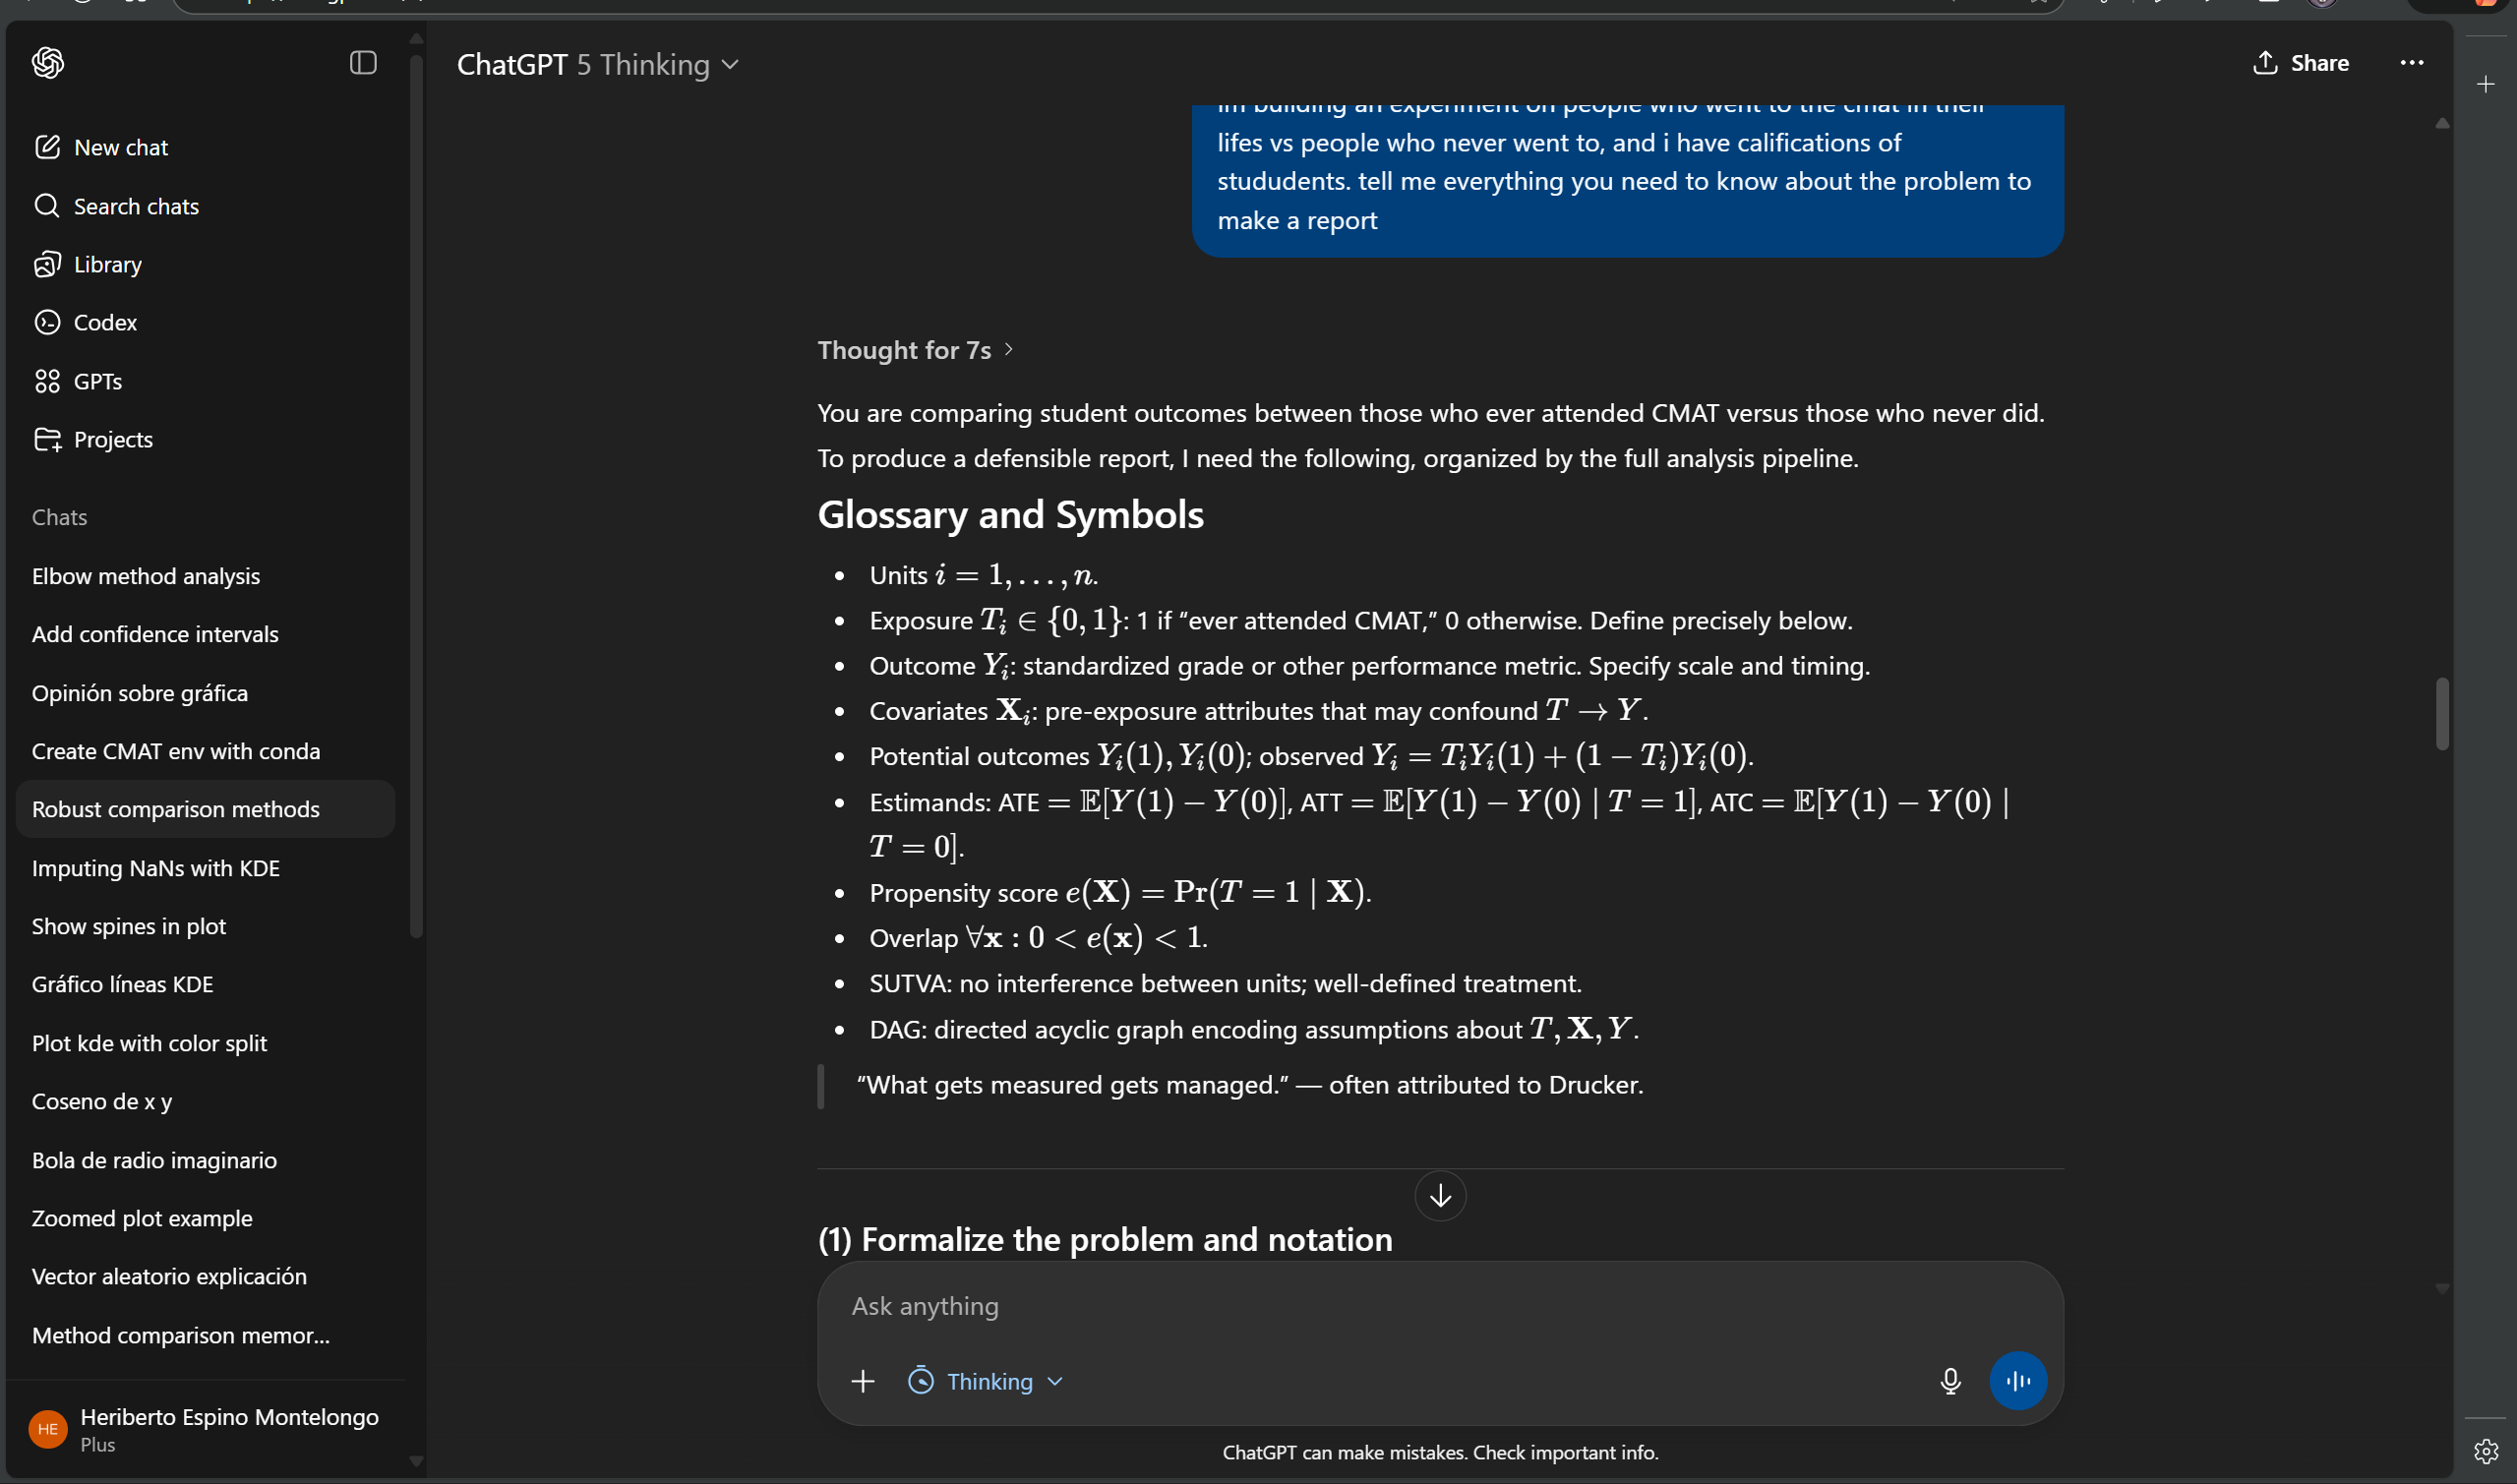